# 🧰 Scikit-Learn — Classical Machine Learning, the Professional Way

> **What you'll learn:** the estimator API, leak-free preprocessing with `ColumnTransformer` and `Pipeline`, choosing the right cross-validation, an honest tour of the model zoo, metrics, hyperparameter search and nested CV, class imbalance with threshold tuning and calibration, clustering and PCA, feature importance, custom transformers, and saving models safely — all on real census data.

| | |
|---|---|
| **Difficulty** | 🟢 Beginner → 🔴 Advanced |
| **Time** | ~5 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [ML Fundamentals From Scratch](01_ML_Fundamentals_From_Scratch.ipynb) (train/test, overfitting, regression, metrics) · [Pandas](../01_Core_Scientific_Computing/02_Pandas.ipynb) (DataFrames, groupby) |
| **Tested with** | Python 3.12 · scikit-learn 1.9 · pandas 3.0 · numpy 2.5 · skops 0.14 |
| **Interview relevance** | ⭐⭐⭐ High — data leakage, pipelines, choosing a CV strategy, nested CV, imbalance and thresholds, calibration, feature importance pitfalls |

## 🤔 What Is Scikit-Learn?

**scikit-learn** (imported as `sklearn`) is the standard Python library for *classical* machine learning — the models that work on tables of numbers and categories: linear and logistic regression, decision trees, random forests, gradient boosting, k-nearest neighbours, clustering, PCA, and more.

Its superpower is **one consistent interface**. Think of a kitchen where every appliance has the same two buttons:

- **`fit`** = *learn* from data (the blender "learns" nothing, but a scaler learns the mean, a model learns its weights)
- **`predict`** or **`transform`** = *use* what was learned on new data

Because every tool has the same buttons, you can chain them into an assembly line called a **Pipeline**, swap one model for another in one line, and evaluate everything with the same cross-validation code.

```
  raw table ──► [ impute ] ──► [ scale / encode ] ──► [ model ] ──► prediction
                 fit+transform   fit+transform         fit+predict
                 └──────────────── one Pipeline object ───────────┘
```

## 🎯 Why It Matters

- **Most business ML is tabular.** Churn, fraud, credit risk, pricing, lead scoring, medical triage — the data is a table, and scikit-learn (plus gradient boosting, next notebook) is the default toolkit.
- **It is the baseline for everything.** Even LLM and deep-learning teams compare against a logistic regression or a gradient-boosted tree first.
- **Its design became the industry vocabulary.** "Estimator", "transformer", "pipeline", "cross-validation", "hyperparameter search" mean the same thing in XGBoost, LightGBM, Keras wrappers, and MLOps tools.
- **In interviews** you will be asked *how you would evaluate a model without fooling yourself*: data leakage, which cross-validation to use, why accuracy misleads on imbalanced data, how to pick a decision threshold, and why `feature_importances_` can lie. This notebook practises exactly that, with real numbers you compute yourself.

## ✅ By the End You Can

- [ ] Explain the estimator API (`fit` / `predict` / `transform`, fitted attributes ending in `_`) and why it prevents leakage when used in a `Pipeline`
- [ ] Build a `ColumnTransformer` pipeline for mixed numeric + categorical data with missing values
- [ ] Choose between `KFold`, `StratifiedKFold`, `GroupKFold`, and `TimeSeriesSplit`, and run nested cross-validation
- [ ] Tune hyperparameters with grid, random, and successive-halving search
- [ ] Handle class imbalance with `class_weight`, `TunedThresholdClassifierCV`, and `CalibratedClassifierCV`
- [ ] Explain impurity vs permutation importance, write a custom transformer, and save/load a model safely

## 📋 Table of Contents

1. [The Estimator API](#1.-The-Estimator-API-🟢)
2. [Train/Test Splits and Stratification](#2.-Train/Test-Splits-and-Stratification-🟢)
3. [Preprocessing Mixed-Type Data](#3.-Preprocessing-Mixed-Type-Data-🟢)
4. [Pipelines Prevent Data Leakage](#4.-Pipelines-Prevent-Data-Leakage-🟡)
5. [Cross-Validation Strategies](#5.-Cross-Validation-Strategies-🟡)
6. [The Model Zoo](#6.-The-Model-Zoo-🟡)
7. [Metrics and Displays](#7.-Metrics-and-Displays-🟢)
8. [Hyperparameter Search](#8.-Hyperparameter-Search-🟡)
9. [Nested Cross-Validation](#9.-Nested-Cross-Validation-🔴)
10. [Class Imbalance, Thresholds, and Calibration](#10.-Class-Imbalance,-Thresholds,-and-Calibration-🔴)
11. [Unsupervised Learning: KMeans, PCA, DBSCAN](#11.-Unsupervised-Learning:-KMeans,-PCA,-DBSCAN-🟡)
12. [Feature Importance](#12.-Feature-Importance-🟡)
13. [Custom Transformers](#13.-Custom-Transformers-🟡)
14. [Persistence and Reproducibility](#14.-Persistence-and-Reproducibility-🟢)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-Adult-Income-Campaign-Targeting) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a package is missing, uncomment the `%pip` line, run it once, then restart the kernel. The notebook downloads one small dataset from OpenML (the *Adult* census table, a few MB) and caches it in `~/scikit_learn_data`.

The `check()` helper gives you instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

In [1]:
# To install (then restart the kernel):  pip install "scikit-learn>=1.8" "pandas>=2.2" "numpy>=2.0" matplotlib skops joblib

import sys
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn

print(f"Python {sys.version.split()[0]} | scikit-learn {sklearn.__version__} | pandas {pd.__version__} | "
      f"numpy {np.__version__} | scipy {scipy.__version__}")

SEED = 42                                   # one seed, passed explicitly as random_state everywhere
rng = np.random.default_rng(SEED)
OUTPUT_DIR = Path("_outputs")               # files we write go here (ignored by git)
OUTPUT_DIR.mkdir(exist_ok=True)
pd.set_option("display.precision", 3)
pd.set_option("display.max_columns", 20)


def check(name, got, expected, hint="", atol=1e-6):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return

    def close(a, b):
        if isinstance(b, (str, bool, set)) or isinstance(a, (str, bool, set)):
            return a == b
        if isinstance(b, dict):
            return isinstance(a, dict) and a.keys() == b.keys() and all(close(a[k], b[k]) for k in b)
        a_arr, b_arr = np.asarray(a), np.asarray(b)
        if a_arr.shape != b_arr.shape:
            return False
        if np.issubdtype(b_arr.dtype, np.number) and np.issubdtype(a_arr.dtype, np.number):
            return bool(np.allclose(a_arr, b_arr, atol=atol, rtol=0))
        return bool(np.array_equal(a_arr, b_arr))

    assert close(got, expected), f"❌ {name}: not quite (got {got!r}). {hint}"
    print(f"✅ {name}: correct!")

Python 3.12.11 | scikit-learn 1.9.1 | pandas 3.0.5 | numpy 2.5.3 | scipy 1.18.1


## 1. The Estimator API 🟢

Everything in scikit-learn is an **estimator**: an object that learns from data with `fit`. There are three flavours:

| Kind | Learns in `fit` | Then you call | Examples |
|---|---|---|---|
| **Transformer** | statistics (mean, categories, …) | `transform(X)` → new features | `StandardScaler`, `OneHotEncoder`, `SimpleImputer`, `PCA` |
| **Predictor** (classifier / regressor) | model parameters | `predict(X)`, `predict_proba(X)`, `score(X, y)` | `LogisticRegression`, `RandomForestClassifier` |
| **Meta-estimator** | wraps other estimators | whatever the inner one offers | `Pipeline`, `GridSearchCV`, `CalibratedClassifierCV` |

Three rules to remember:
1. **Hyperparameters** (your choices) go in the constructor: `LogisticRegression(C=0.1)`.
2. **Learned values** appear *after* `fit` as attributes ending in an underscore: `scaler.mean_`, `model.coef_`.
3. `fit` returns the estimator itself, so `model.fit(X, y).predict(X_new)` works.

We start with a small built-in medical dataset: 569 breast tumours, 30 measurements each. ⚠️ Its labels are easy to misread: **0 = malignant, 1 = benign** — check `target_names`.

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

cancer = load_breast_cancer(as_frame=True)
X_bc, y_bc = cancer.data, cancer.target
print("X:", X_bc.shape, "| label meaning:", dict(enumerate(cancer.target_names.tolist())))
print("class counts:", y_bc.value_counts().sort_index().to_dict())

# A TRANSFORMER: fit learns per-column mean and std, transform applies them
scaler = StandardScaler()
scaler.fit(X_bc)
print("\nlearned means (first 3):", scaler.mean_[:3].round(2))
X_scaled = scaler.transform(X_bc)
print("scaled column means ≈ 0:", np.allclose(X_scaled.mean(axis=0), 0))

# A PREDICTOR: fit learns tree splits, predict uses them
tree = DecisionTreeClassifier(max_depth=3, random_state=SEED).fit(X_bc, y_bc)
print("\nclasses_          :", tree.classes_)
print("n_features_in_    :", tree.n_features_in_)
print("feature_names_in_ :", list(tree.feature_names_in_[:3]), "…")
print("first 5 predictions:", tree.predict(X_bc.iloc[:5]))
print("first 2 probabilities:\n", tree.predict_proba(X_bc.iloc[:2]).round(3))

X: (569, 30) | label meaning: {0: 'malignant', 1: 'benign'}
class counts: {0: 212, 1: 357}

learned means (first 3): [14.13 19.29 91.97]
scaled column means ≈ 0: True

classes_          : [0 1]
n_features_in_    : 30
feature_names_in_ : ['mean radius', 'mean texture', 'mean perimeter'] …
first 5 predictions: [0 0 0 0 0]
first 2 probabilities:
 [[1.    0.   ]
 [0.994 0.006]]


In [3]:
from sklearn.base import clone
from sklearn.exceptions import NotFittedError

fresh = DecisionTreeClassifier(max_depth=3)
try:
    fresh.predict(X_bc)                           # using an estimator before fit
except NotFittedError as err:
    print("NotFittedError:", str(err)[:90], "…")

print("\nget_params():", {k: v for k, v in tree.get_params().items() if k in ("max_depth", "random_state")})
twin = clone(tree)                                # same hyperparameters, NOT fitted
print("clone keeps params:", twin.get_params()["max_depth"], "| clone is fitted:", hasattr(twin, "classes_"))

NotFittedError: This DecisionTreeClassifier instance is not fitted yet. Call 'fit' with appropriate argume …

get_params(): {'max_depth': 3, 'random_state': 42}
clone keeps params: 3 | clone is fitted: False


`clone` is how cross-validation and grid search create a fresh, unfitted copy of your model for every fold — so nothing learned in one fold can sneak into another.

### ✍️ Your Turn

Fit a `StandardScaler` on `X_small` and store the **learned column means** (a fitted attribute) in `learned_means`.

In [4]:
X_small = np.array([[1.0, 10.0],
                    [2.0, 20.0],
                    [3.0, 30.0]])
learned_means = None  # TODO: your code here
check("learned_means", learned_means, [2.0, 20.0], hint="Fitted attributes end with '_' — try StandardScaler().fit(X_small).mean_")

⏳ learned_means: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
X_small = np.array([[1.0, 10.0], [2.0, 20.0], [3.0, 30.0]])
learned_means = StandardScaler().fit(X_small).mean_
check("learned_means", learned_means, [2.0, 20.0])
```

The scaler also learned `scale_` (the standard deviations) and `n_features_in_`.
</details>

> 💡 **Interview angle:** "What is the difference between a hyperparameter and a parameter?" — hyperparameters are set *before* training in the constructor (`max_depth`, `C`); parameters are *learned* by `fit` and stored with a trailing underscore (`coef_`, `tree_`). Never put learning logic in `__init__`.

## 2. Train/Test Splits and Stratification 🟢

To know how a model does on **unseen** data, we hide some data from it:

- **Training set** — the model learns from it (and we tune on it with cross-validation).
- **Test set** — locked in a drawer until the very end; used **once** to report the final score.

**Stratification** means the split keeps the class proportions the same in both parts. With a rare class and a small dataset, a random split can easily put too few positives in the test set.

Now the main dataset: **Adult** (1994 US census, 48,842 people). The task: predict whether a person earns **more than $50K per year** from age, education, occupation, hours worked, etc. It has numbers, categories, and missing values — like real business data.

In [5]:
from sklearn.datasets import fetch_openml

adult = fetch_openml("adult", version=2, as_frame=True)       # cached after the first download
X_adult = adult.data
y_adult = (adult.target == ">50K").astype(int)               # 1 = earns more than $50K
print("X:", X_adult.shape, "| positive rate (>50K):", round(y_adult.mean(), 3))
print("\ncolumn types:", X_adult.dtypes.astype(str).value_counts().to_dict())
print("missing values:", X_adult.isna().sum()[lambda s: s > 0].to_dict())
X_adult.head(3)

X: (48842, 14) | positive rate (>50K): 0.239

column types: {'category': 8, 'int64': 6}
missing values: {'workclass': 2799, 'occupation': 2809, 'native-country': 857}


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States


In [6]:
from sklearn.model_selection import train_test_split

# How much does the positive rate of a small test set wobble, with and without stratification?
small = X_adult.sample(300, random_state=SEED)
y_small = y_adult.loc[small.index]
rates = {"random": [], "stratified": []}
for seed in range(200):
    _, _, _, y_te = train_test_split(small, y_small, test_size=0.2, random_state=seed)
    rates["random"].append(y_te.mean())
    _, _, _, y_te = train_test_split(small, y_small, test_size=0.2, random_state=seed, stratify=y_small)
    rates["stratified"].append(y_te.mean())
for kind, r in rates.items():
    print(f"{kind:10s} test positive rate over 200 splits: min {min(r):.3f}  max {max(r):.3f}  std {np.std(r):.4f}")

random     test positive rate over 200 splits: min 0.133  max 0.417  std 0.0493
stratified test positive rate over 200 splits: min 0.250  max 0.250  std 0.0000


In [7]:
# The real split for the rest of the notebook: 80% train, 20% test, stratified, fixed seed
X_train, X_test, y_train, y_test = train_test_split(
    X_adult, y_adult, test_size=0.2, stratify=y_adult, random_state=SEED
)
print(f"train {X_train.shape} positive rate {y_train.mean():.3f} | test {X_test.shape} positive rate {y_test.mean():.3f}")
print("🔒 X_test / y_test stay locked until the mini project's final evaluation.")

train (39073, 14) positive rate 0.239 | test (9769, 14) positive rate 0.239
🔒 X_test / y_test stay locked until the mini project's final evaluation.


When you also need a **validation set** (for early stopping or picking a threshold by eye), split the *training* set again — never borrow from the test set.

### ✍️ Your Turn

Split the breast-cancer data with `test_size=0.25`, `random_state=0`, **stratified on the labels**. Store the share of **malignant** tumours in the test set (rounded to 3 decimals) in `test_malignant_share`. Remember: malignant is label **0**.

In [8]:
test_malignant_share = None  # TODO: your code here
check("test_malignant_share", test_malignant_share, 0.371, atol=1e-9,
      hint="train_test_split(X_bc, y_bc, test_size=0.25, random_state=0, stratify=y_bc), then round((y_te == 0).mean(), 3)")

⏳ test_malignant_share: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
_, _, _, y_te_bc = train_test_split(X_bc, y_bc, test_size=0.25, random_state=0, stratify=y_bc)
test_malignant_share = round(float((y_te_bc == 0).mean()), 3)
check("test_malignant_share", test_malignant_share, 0.371, atol=1e-9)
```

The full dataset is 37.3% malignant; stratification keeps the test set as close to that as a whole number of tumours allows.
</details>

> 💡 **Interview angle:** "Why stratify?" — so rare classes are represented in the same proportion in every split; it lowers the variance of your evaluation. For regression, you can stratify on binned targets. For time series or grouped data, a random split is wrong altogether (Section 5).

## 3. Preprocessing Mixed-Type Data 🟢

Most models need a table of **numbers with no missing values**. Real tables have neither. The standard building blocks:

| Problem | Transformer | What `fit` learns |
|---|---|---|
| Missing values | `SimpleImputer(strategy="median")` / `"most_frequent"` | the fill value per column |
| Features on different scales | `StandardScaler()` | mean and std per column |
| Categories (text labels) | `OneHotEncoder(handle_unknown=...)` | the list of categories |
| Very many categories | `TargetEncoder()` | the (smoothed) average target per category |

A **`ColumnTransformer`** sends different columns to different transformers and glues the results side by side:

```
  age, hours-per-week, …  ──► impute median ─► scale ─────┐
                                                          ├──► one numeric matrix
  workclass, occupation, … ──► impute mode ─► one-hot ────┘
```

In [9]:
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder

numeric_cols = make_column_selector(dtype_include="number")      # picks columns by dtype at fit time
categorical_cols = make_column_selector(dtype_include="category")

preprocessor = ColumnTransformer(
    [
        ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), numeric_cols),
        ("cat", make_pipeline(
            SimpleImputer(strategy="most_frequent"),
            # infrequent_if_exist: categories seen < 50 times share one column, unseen ones map there too
            OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=50, sparse_output=False),
        ), categorical_cols),
    ],
    verbose_feature_names_out=False,
)
preprocessor.set_output(transform="pandas")    # get a DataFrame with real column names back

X_train_prep = preprocessor.fit_transform(X_train)     # fit on TRAIN only
print("before:", X_train.shape, "→ after:", X_train_prep.shape)
print("any missing left:", X_train_prep.isna().any().any())
print("some output columns:", list(X_train_prep.columns[[0, 5, 6, 30, -1]]))
X_train_prep.iloc[:3, :8]

before: (39073, 14) → after: (39073, 86)
any missing left: False
some output columns: ['age', 'hours-per-week', 'workclass_Federal-gov', 'marital-status_Married-civ-spouse', 'native-country_infrequent_sklearn']


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov
34342,2.351,-1.068,-0.419,-0.144,-0.22,-1.889,0.0,0.0
18559,-1.579,1.334,-1.585,-0.144,-0.22,-2.453,0.0,0.0
12477,-0.851,-0.935,-0.419,-0.144,-0.22,-0.037,0.0,0.0


In [10]:
# handle_unknown matters in production: a category never seen in training arrives
new_person = X_train.iloc[[0]].copy()
new_person["native-country"] = pd.Categorical(["Atlantis"])
row = preprocessor.transform(new_person)
country_cols = [c for c in row.columns if c.startswith("native-country")]
print("unseen country goes to:", [c for c in country_cols if row[c].iloc[0] == 1])

unseen country goes to:

 ['native-country_infrequent_sklearn']


**Target encoding** replaces each category with the average target for that category (smoothed toward the overall average). It keeps one column even for thousands of categories. The danger: a row's own label leaks into its encoding. `TargetEncoder` avoids that with **cross fitting** — during `fit_transform`, each row is encoded using statistics from the *other* folds. That is why `fit_transform(X)` is **not** the same as `fit(X).transform(X)` here.

In [11]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import TargetEncoder

country = X_train[["native-country"]]
encoder = TargetEncoder(cv=StratifiedKFold(5, shuffle=True, random_state=SEED))
cross_fitted = encoder.fit_transform(country, y_train)   # training rows: out-of-fold encodings
plain = encoder.transform(country)                        # new data: uses the full-training statistics
print("fit_transform == transform on the same rows?", np.allclose(cross_fitted, plain))
print("encoding for 3 countries:",
      dict(zip(encoder.categories_[0][:3].tolist(), encoder.encodings_[0][:3].round(3).tolist())))

fit_transform == transform on the same rows? False
encoding for 3 countries: {'Cambodia': 0.36, 'Canada': 0.317, 'China': 0.293}


### ✍️ Your Turn

Build a `ColumnTransformer` named `ct` that one-hot encodes `city` (with `handle_unknown="ignore"`) under the name `"cat"` and scales `age` under the name `"num"`, fit it on `people`, and store `list(ct.get_feature_names_out())` in `feature_names`.

In [12]:
people = pd.DataFrame({"city": ["Paris", "Tokyo", "Paris"], "age": [25, 32, 47]})
feature_names = None  # TODO: your code here
check("feature_names", feature_names, ["cat__city_Paris", "cat__city_Tokyo", "num__age"],
      hint="ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), ['city']), ('num', StandardScaler(), ['age'])])")

⏳ feature_names: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
people = pd.DataFrame({"city": ["Paris", "Tokyo", "Paris"], "age": [25, 32, 47]})
ct = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["city"]),
    ("num", StandardScaler(), ["age"]),
])
ct.fit(people)
feature_names = list(ct.get_feature_names_out())
check("feature_names", feature_names, ["cat__city_Paris", "cat__city_Tokyo", "num__age"])
```

The `name__` prefix tells you which transformer produced each column; `verbose_feature_names_out=False` removes it.
</details>

> 💡 **Interview angle:** "One-hot vs target encoding?" — one-hot is safe and interpretable but explodes with high cardinality; target encoding stays compact but can leak the label, so it must be cross-fitted (as `TargetEncoder.fit_transform` does) and fit only on training folds.

## 4. Pipelines Prevent Data Leakage 🟡

**Data leakage** = information from the evaluation data sneaks into training, so your score looks better than reality. The most common way: running a *fitting* step (scaling, imputing, selecting features, encoding) on the **whole dataset before** cross-validation.

A **`Pipeline`** chains steps into one estimator. When cross-validation calls `pipeline.fit(train_fold)`, *every* step is fit on that training fold only, and the validation fold is only ever `transform`ed. Leakage becomes impossible by construction.

Let's prove how big the effect can be with a **controlled synthetic example**: 200 rows of **pure random noise** with random labels. No model can honestly beat 50% accuracy.

In [13]:
from sklearn.feature_selection import SelectKBest
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, cross_val_score

noise_rng = np.random.default_rng(0)
X_noise = noise_rng.normal(size=(200, 5000))       # 5,000 meaningless features
y_noise = noise_rng.integers(0, 2, size=200)        # coin-flip labels
cv5 = StratifiedKFold(5, shuffle=True, random_state=0)

# ❌ select the 20 "best" features using ALL rows, then cross-validate
selected = SelectKBest(k=20).fit(X_noise, y_noise).transform(X_noise)
leaky = cross_val_score(LogisticRegression(), selected, y_noise, cv=cv5).mean()

# ✅ selection is a pipeline step, so it is re-fit inside every training fold
honest = cross_val_score(make_pipeline(SelectKBest(k=20), LogisticRegression()), X_noise, y_noise, cv=cv5).mean()

print(f"❌ leaky CV accuracy : {leaky:.3f}")
print(f"✅ honest CV accuracy: {honest:.3f}   (chance is 0.5)")
print(f"→ leakage inflated accuracy by {leaky - honest:.3f} on data with no signal at all")

❌ leaky CV accuracy : 0.795
✅ honest CV accuracy: 0.545   (chance is 0.5)
→ leakage inflated accuracy by 0.250 on data with no signal at all


The leaky version chose features that *happen* to correlate with the labels of the validation rows too — it peeked at the answers. Now a real pipeline on Adult:

In [14]:
adult_model = make_pipeline(preprocessor, LogisticRegression(max_iter=1000))
print("step names:", list(adult_model.named_steps))

scores = cross_val_score(adult_model, X_train, y_train, cv=cv5, scoring="roc_auc", n_jobs=-1)
print(f"5-fold ROC-AUC: {scores.mean():.3f} ± {scores.std():.3f}")

# Parameters of inner steps are addressed as <step>__<param>, even through nesting
print("example nested param:", "columntransformer__cat__onehotencoder__min_frequency =",
      adult_model.get_params()["columntransformer__cat__onehotencoder__min_frequency"])

step names: ['columntransformer', 'logisticregression']


5-fold ROC-AUC: 0.905 ± 0.003
example nested param: columntransformer__cat__onehotencoder__min_frequency = 50


`make_pipeline` names each step after its class in lowercase (`logisticregression`); `Pipeline([("model", LogisticRegression())])` lets you choose names.

### ✍️ Your Turn

Write `param_grid` so that the grid search below tries `C` values `0.001` and `1.0` for the **logistic regression step** of the pipeline. You only need the correct key name.

In [15]:
bc_pipe = make_pipeline(StandardScaler(), LogisticRegression())
param_grid = None  # TODO: {"<step name>__<parameter>": [0.001, 1.0]}
best_C = None if param_grid is None else GridSearchCV(bc_pipe, param_grid, cv=cv5).fit(X_bc, y_bc).best_params_
check("best_C", best_C, {"logisticregression__C": 1.0}, hint="make_pipeline names the step 'logisticregression'; join with a double underscore.")

⏳ best_C: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
bc_pipe = make_pipeline(StandardScaler(), LogisticRegression())
param_grid = {"logisticregression__C": [0.001, 1.0]}
best_C = GridSearchCV(bc_pipe, param_grid, cv=cv5).fit(X_bc, y_bc).best_params_
check("best_C", best_C, {"logisticregression__C": 1.0})
```

`C` is the *inverse* regularization strength: `C=0.001` shrinks the weights so hard that the model underfits.
</details>

> 💡 **Interview angle:** "What is data leakage and how do you prevent it?" — any information from validation/test data (or from the future) influencing training. Put every fitted preprocessing step inside a `Pipeline`, split before exploring, and respect groups and time order when splitting.

## 5. Cross-Validation Strategies 🟡

**Cross-validation (CV)** splits the training data into *k* folds, trains on k−1 of them, validates on the remaining one, and repeats k times. You get k scores instead of one lucky (or unlucky) number.

The *splitter* you choose must mirror how the model will meet new data in real life:

| Splitter | Use when | What it guarantees |
|---|---|---|
| `KFold` | regression, rows independent | every row validated exactly once |
| `StratifiedKFold` | classification (the default for classifiers when you pass `cv=5`) | class proportions preserved per fold |
| `GroupKFold` | several rows per patient / user / store / session | a group is never in both train and validation |
| `TimeSeriesSplit` | rows ordered in time, predicting the future | validation data is always *after* training data |

First, why shuffling and stratification matter: if the file happens to be sorted by label, plain `KFold` without shuffling produces folds with a single class.

In [16]:
from sklearn.model_selection import GroupKFold, KFold, TimeSeriesSplit

y_sorted = np.sort(y_bc.to_numpy())                 # imagine the file was sorted by label
dummy_X = np.zeros((len(y_sorted), 1))
for name, splitter in [("KFold (no shuffle)", KFold(5)),
                       ("StratifiedKFold", StratifiedKFold(5, shuffle=True, random_state=SEED))]:
    rates = [round(float(y_sorted[val].mean()), 2) for _, val in splitter.split(dummy_X, y_sorted)]
    print(f"{name:20s} benign share per validation fold: {rates}")

KFold (no shuffle)   benign share per validation fold: [0.0, 0.14, 1.0, 1.0, 1.0]
StratifiedKFold      benign share per validation fold: [0.62, 0.62, 0.63, 0.63, 0.63]


**Groups.** Below is a **controlled synthetic example** of a medical study: 60 patients, 10 visits each. Each patient has a personal "fingerprint" in the measurements that has **nothing to do** with the diagnosis. A 1-nearest-neighbour model can memorise fingerprints: if another visit of the same patient is in the training fold, it just copies that patient's label.

In [17]:
from sklearn.neighbors import KNeighborsClassifier

pat_rng = np.random.default_rng(1)
n_patients, visits = 60, 10
patient_id = np.repeat(np.arange(n_patients), visits)
diagnosis = pat_rng.integers(0, 2, n_patients)[patient_id]            # label fixed per patient
fingerprint = pat_rng.normal(size=(n_patients, 5))[patient_id]         # unrelated to the label
X_visits = fingerprint + 0.1 * pat_rng.normal(size=(n_patients * visits, 5))

knn1 = KNeighborsClassifier(n_neighbors=1)
random_cv = cross_val_score(knn1, X_visits, diagnosis, cv=KFold(5, shuffle=True, random_state=0)).mean()
group_cv = cross_val_score(knn1, X_visits, diagnosis, cv=GroupKFold(5), groups=patient_id).mean()
print(f"❌ KFold      accuracy: {random_cv:.3f}  (same patient in train and validation)")
print(f"✅ GroupKFold accuracy: {group_cv:.3f}  (new patients only — the honest answer)")

❌ KFold      accuracy: 0.998  (same patient in train and validation)
✅ GroupKFold accuracy: 0.530  (new patients only — the honest answer)


In [18]:
# Time: every validation block comes strictly after its training block; `gap` leaves a buffer
tscv = TimeSeriesSplit(n_splits=4, test_size=2, gap=1)
for fold, (tr, va) in enumerate(tscv.split(np.arange(12))):
    print(f"fold {fold}: train {tr.min()}–{tr.max()}  gap  validate {va.tolist()}")

fold 0: train 0–2  gap  validate [4, 5]
fold 1: train 0–4  gap  validate [6, 7]
fold 2: train 0–6  gap  validate [8, 9]
fold 3: train 0–8  gap  validate [10, 11]


In [19]:
from sklearn.model_selection import cross_validate

# cross_validate: several metrics + train scores + timing in one call
results = cross_validate(
    make_pipeline(StandardScaler(), LogisticRegression()), X_bc, y_bc,
    cv=cv5, scoring=["accuracy", "roc_auc"], return_train_score=True,
)
print(pd.DataFrame(results).mean().round(4).to_string())

fit_time          0.002
score_time        0.002
test_accuracy     0.979
train_accuracy    0.988
test_roc_auc      0.996
train_roc_auc     0.998


### ✍️ Your Turn

Using `GroupKFold(n_splits=4)` on `X_visits` / `diagnosis` / `patient_id`, build a list `overlaps` with, for each fold, **the number of patients that appear in both the training and the validation part**.

In [20]:
overlaps = None  # TODO: loop over GroupKFold(4).split(X_visits, diagnosis, groups=patient_id)
check("overlaps", overlaps, [0, 0, 0, 0], hint="len(set(patient_id[train]) & set(patient_id[val])) for each fold")

⏳ overlaps: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
overlaps = [
    len(set(patient_id[tr]) & set(patient_id[va]))
    for tr, va in GroupKFold(n_splits=4).split(X_visits, diagnosis, groups=patient_id)
]
check("overlaps", overlaps, [0, 0, 0, 0])
```

Try the same with `KFold(4, shuffle=True, random_state=0)` — almost every patient lands on both sides.
</details>

> 💡 **Interview angle:** "Your model scored 0.99 in CV and 0.60 in production" — first question: *was the CV split like production?* Same user/patient in both folds → `GroupKFold`; predicting the future → `TimeSeriesSplit`; both → `StratifiedGroupKFold` or a time split by group.

## 6. The Model Zoo 🟡

Scikit-learn has dozens of models. You only need a handful to start — and an honest idea of when each shines:

| Model | Needs scaling? | Strengths | Weaknesses |
|---|---|---|---|
| `LogisticRegression` / `Ridge` | ✅ yes | fast, interpretable coefficients, well-calibrated probabilities, strong baseline | only linear boundaries unless you engineer features |
| `SVC` (RBF kernel) | ✅ yes | flexible boundaries on small/medium data | training time grows roughly quadratically with rows; no native probabilities |
| `KNeighborsClassifier` | ✅ yes | no training, simple | slow predictions, suffers in high dimensions |
| `DecisionTreeClassifier` | ❌ no | readable rules | a deep tree overfits badly |
| `RandomForestClassifier` | ❌ no | robust, little tuning | large models, slower predictions |
| `HistGradientBoostingClassifier` | ❌ no | usually the most accurate on tables; native missing values and categories | more hyperparameters; less interpretable |

Rule of thumb: **start with a dummy baseline and logistic regression, then try gradient boosting.** Let's compare them all with the same CV on a 8,000-row sample of the training set (SVC and kNN get slow on all 39k rows).

In [21]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.svm import SVC

zoo_idx = X_train.sample(8000, random_state=SEED).index
X_zoo, y_zoo = X_train.loc[zoo_idx], y_train.loc[zoo_idx]

zoo = {
    "Dummy (most frequent)": make_pipeline(preprocessor, DummyClassifier()),
    "LogisticRegression": make_pipeline(preprocessor, LogisticRegression(max_iter=1000)),
    "kNN (k=25)": make_pipeline(preprocessor, KNeighborsClassifier(n_neighbors=25)),
    "SVC (RBF)": make_pipeline(preprocessor, SVC()),
    "DecisionTree (no limit)": make_pipeline(preprocessor, DecisionTreeClassifier(random_state=SEED)),
    "DecisionTree (depth 8)": make_pipeline(preprocessor, DecisionTreeClassifier(max_depth=8, random_state=SEED)),
    "RandomForest": make_pipeline(preprocessor, RandomForestClassifier(n_estimators=300, min_samples_leaf=2,
                                                                       random_state=SEED, n_jobs=-1)),
    # HGB handles pandas 'category' columns and NaN natively: no preprocessing at all
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=SEED),
}
rows = []
for name, model in zoo.items():
    res = cross_validate(model, X_zoo, y_zoo, cv=cv5, scoring="roc_auc", return_train_score=True, n_jobs=5)
    rows.append({"model": name, "train AUC": res["train_score"].mean(), "CV AUC": res["test_score"].mean(),
                 "CV std": res["test_score"].std(), "fit s": res["fit_time"].mean()})
zoo_table = pd.DataFrame(rows).set_index("model").sort_values("CV AUC", ascending=False)
zoo_table

,train AUC,CV AUC,CV std,fit s
model,,,,
HistGradientBoosting,0.982,0.917,0.011,1.647
RandomForest,0.982,0.909,0.011,0.494
LogisticRegression,0.908,0.904,0.010,0.057
SVC (RBF),0.928,0.897,0.006,0.539
kNN (k=25),0.909,0.887,0.006,0.042
DecisionTree (depth 8),0.925,0.882,0.006,0.056
DecisionTree (no limit),1.000,0.738,0.013,0.066
Dummy (most frequent),0.500,0.500,0.000,0.062


In [22]:
best_name = zoo_table.index[0]
gap = zoo_table["train AUC"] - zoo_table["CV AUC"]
print(f"best CV AUC: {best_name} ({zoo_table.loc[best_name, 'CV AUC']:.3f})")
print(f"largest train–CV gap (overfitting): {gap.idxmax()} ({gap.max():.3f})")
print(f"logistic regression vs best: {zoo_table.loc['LogisticRegression', 'CV AUC']:.3f} vs "
      f"{zoo_table.loc[best_name, 'CV AUC']:.3f}")

best CV AUC: HistGradientBoosting (0.917)
largest train–CV gap (overfitting): DecisionTree (no limit) (0.262)
logistic regression vs best: 0.904 vs 0.917


Regression works the same way — only the metric changes. `root_mean_squared_error` (RMSE) is in the target's units; scorers are "higher is better", so CV uses `neg_root_mean_squared_error`.

In [23]:
from sklearn.datasets import load_diabetes
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error

X_dia, y_dia = load_diabetes(return_X_y=True, as_frame=True)       # 442 patients, target = disease progression
reg_cv = KFold(5, shuffle=True, random_state=SEED)
reg_scores = {}
for name, reg in [("mean baseline", DummyRegressor()),
                  ("Ridge", make_pipeline(StandardScaler(), Ridge(alpha=1.0))),
                  ("HistGradientBoosting", HistGradientBoostingRegressor(random_state=SEED))]:
    reg_scores[name] = -cross_val_score(reg, X_dia, y_dia, cv=reg_cv, scoring="neg_root_mean_squared_error").mean()
    print(f"{name:22s} CV RMSE {reg_scores[name]:6.2f}")

# the same metric as a plain function, on one hold-out fold
tr_idx, va_idx = next(reg_cv.split(X_dia))
ridge = make_pipeline(StandardScaler(), Ridge()).fit(X_dia.iloc[tr_idx], y_dia.iloc[tr_idx])
print(f"root_mean_squared_error on fold 0: {root_mean_squared_error(y_dia.iloc[va_idx], ridge.predict(X_dia.iloc[va_idx])):.2f}")
print("lowest CV RMSE:", min(reg_scores, key=reg_scores.get))

mean baseline          CV RMSE  77.19
Ridge                  CV RMSE  54.83


HistGradientBoosting   CV RMSE  58.55
root_mean_squared_error on fold 0: 53.78
lowest CV RMSE: Ridge


On a tiny dataset with mostly linear structure, the simple model can win — which is exactly why you always compare against a linear baseline.

> 💡 **Interview angle:** "Which models need feature scaling?" — anything based on distances or gradient-trained weights with a penalty (kNN, SVM, logistic/linear regression with regularization, PCA, neural nets). Tree models split on one feature at a time, so monotonic rescaling does not change them.

## 7. Metrics and Displays 🟢

**Accuracy** = share of correct predictions. On Adult, predicting "≤50K" for *everyone* is already ~76% accurate — and completely useless. For a positive class ("earns >50K"):

```
                   predicted 0        predicted 1
  actual 0     TN (correct no)    FP (false alarm)
  actual 1     FN (missed)        TP (found it)

  precision = TP / (TP + FP)   "when I say yes, how often am I right?"
  recall    = TP / (TP + FN)   "of all real yeses, how many did I find?"
  F1        = harmonic mean of precision and recall
```

**ROC-AUC** measures how well the model *ranks* positives above negatives across all thresholds (0.5 = random). **Average precision (PR-AUC)** focuses on the positive class and is more informative when positives are rare (its random baseline is the positive rate, not 0.5).

To look at predictions without touching the test set, we carve a **validation set** out of the training data.

In [24]:
from sklearn.metrics import (ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay,
                             average_precision_score, classification_report, roc_auc_score)

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.25, stratify=y_train, random_state=SEED)
logreg = make_pipeline(preprocessor, LogisticRegression(max_iter=1000)).fit(X_tr, y_tr)
val_pred = logreg.predict(X_val)
val_proba = logreg.predict_proba(X_val)[:, 1]

print(classification_report(y_val, val_pred, target_names=["<=50K", ">50K"], digits=3))
print(f"ROC-AUC {roc_auc_score(y_val, val_proba):.3f} | average precision {average_precision_score(y_val, val_proba):.3f} "
      f"(random baseline {y_val.mean():.3f})")

              precision    recall  f1-score   support

       <=50K      0.880     0.931     0.905      7432
        >50K      0.731     0.597     0.657      2337

    accuracy                          0.851      9769
   macro avg      0.806     0.764     0.781      9769
weighted avg      0.845     0.851     0.846      9769

ROC-AUC 0.907 | average precision 0.767 (random baseline 0.239)


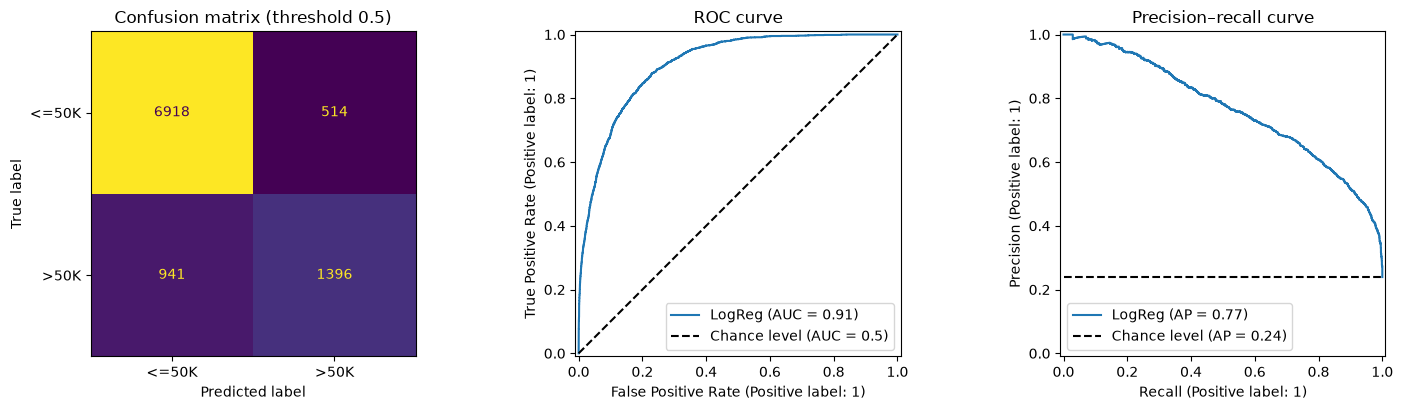

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
ConfusionMatrixDisplay.from_predictions(y_val, val_pred, display_labels=["<=50K", ">50K"], ax=axes[0], colorbar=False)
axes[0].set_title("Confusion matrix (threshold 0.5)")
RocCurveDisplay.from_predictions(y_val, val_proba, name="LogReg", ax=axes[1], plot_chance_level=True)
axes[1].set_title("ROC curve")
PrecisionRecallDisplay.from_predictions(y_val, val_proba, name="LogReg", ax=axes[2], plot_chance_level=True)
axes[2].set_title("Precision–recall curve")
plt.tight_layout()
plt.show()

### ✍️ Your Turn

Compute the 5-fold CV **accuracy** of `DummyClassifier(strategy="most_frequent")` on `X_train`, `y_train` and store the mean in `dummy_accuracy`. The checker compares it with the share of people earning ≤50K.

In [26]:
dummy_accuracy = None  # TODO: your code here
check("dummy_accuracy", dummy_accuracy, 1 - y_train.mean(), atol=1e-3,
      hint="cross_val_score(DummyClassifier(strategy='most_frequent'), X_train, y_train, cv=5).mean()")

⏳ dummy_accuracy: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
dummy_accuracy = cross_val_score(DummyClassifier(strategy="most_frequent"), X_train, y_train, cv=5).mean()
check("dummy_accuracy", dummy_accuracy, 1 - y_train.mean(), atol=1e-3)
```

A model that never predicts ">50K" is ~76% accurate — that is the **accuracy paradox**. Always report a baseline.
</details>

> 💡 **Interview angle:** "ROC-AUC or PR-AUC for a 1%-positive fraud problem?" — PR-AUC (average precision): ROC-AUC can look great because the huge number of true negatives keeps the false-positive *rate* tiny, while precision reveals how many alerts are wrong.

## 8. Hyperparameter Search 🟡

Hyperparameters (tree depth, learning rate, `C`) are chosen by trying candidates with cross-validation:

| Search | How | When |
|---|---|---|
| `GridSearchCV` | every combination of a list of values | few hyperparameters, small grids |
| `RandomizedSearchCV` | `n_iter` random draws from distributions | many hyperparameters; usually finds good values faster |
| `HalvingRandomSearchCV` *(experimental)* | many candidates on little data, keep the best third, give them 3× more data, repeat | large search spaces, expensive fits |

All of them then **refit** the best candidate on the whole training set (`refit=True`), so `search.predict` uses it.

In [27]:
from scipy.stats import loguniform, randint
from sklearn.experimental import enable_halving_search_cv  # noqa: F401  (unlocks the experimental import below)
from sklearn.model_selection import HalvingRandomSearchCV, RandomizedSearchCV

hgb = HistGradientBoostingClassifier(random_state=SEED)
search_cv = StratifiedKFold(3, shuffle=True, random_state=SEED)
searches = {
    "Grid (3×3)": GridSearchCV(hgb, {"learning_rate": [0.03, 0.1, 0.3], "max_leaf_nodes": [7, 31, 63]},
                               cv=search_cv, scoring="roc_auc", n_jobs=-1),
    "Random (9 draws)": RandomizedSearchCV(hgb, {"learning_rate": loguniform(0.01, 0.5), "max_leaf_nodes": randint(5, 100),
                                                 "l2_regularization": loguniform(1e-3, 10)},
                                           n_iter=9, cv=search_cv, scoring="roc_auc", n_jobs=-1, random_state=SEED),
    "Halving random (27 start)": HalvingRandomSearchCV(hgb, {"learning_rate": loguniform(0.01, 0.5), "max_leaf_nodes": randint(5, 100),
                                                             "l2_regularization": loguniform(1e-3, 10)},
                                                       # rounds: 27 candidates on 800 rows → 9 on 2,400 → 3 on 7,200
                                                       n_candidates=27, factor=3, min_resources=800, cv=search_cv, scoring="roc_auc",
                                                       n_jobs=-1, random_state=SEED),
}
search_rows = []
for name, search in searches.items():
    start = time.perf_counter()
    search.fit(X_zoo, y_zoo)
    search_rows.append({"search": name, "candidates tried": len(search.cv_results_["params"]),
                        "best CV AUC": search.best_score_, "seconds": time.perf_counter() - start,
                        "best params": {k: round(v, 3) if isinstance(v, float) else v for k, v in search.best_params_.items()}})
pd.DataFrame(search_rows).set_index("search")

,candidates tried,best CV AUC,seconds,best params
search,,,,
Grid (3×3),9,0.918,3.780,"{'learning_rate': 0.1, 'max_leaf_nodes': 7}"
Random (9 draws),9,0.916,3.892,"{'l2_regularization': 0.003, 'learning_rate': ..."
Halving random (27 start),39,0.914,12.199,"{'l2_regularization': 8.569, 'learning_rate': ..."


Halving search's `best_score_` is measured only on the last (largest) round, so compare searches by re-evaluating their winners — or, better, with nested CV (next section).

**Validation curves** show one hyperparameter's effect on train vs validation score (underfitting on the left, overfitting on the right). **Learning curves** show whether more data would help.

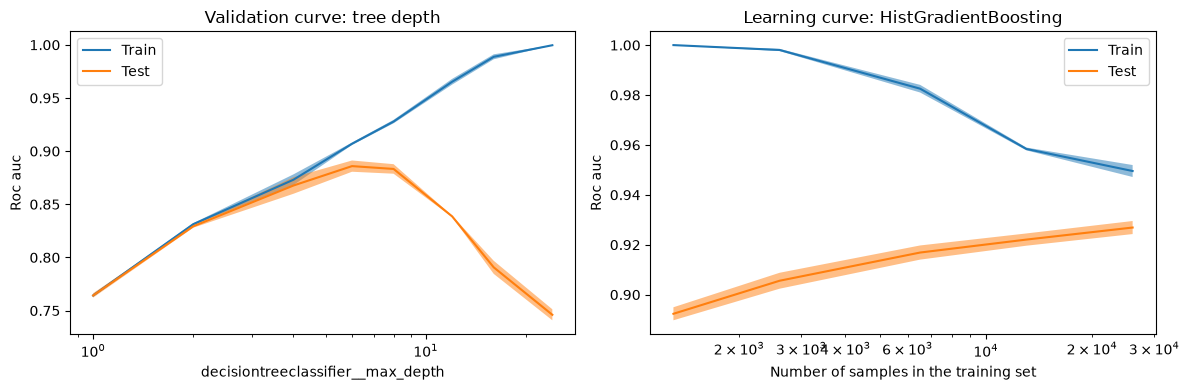

In [28]:
from sklearn.model_selection import LearningCurveDisplay, ValidationCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ValidationCurveDisplay.from_estimator(
    make_pipeline(preprocessor, DecisionTreeClassifier(random_state=SEED)), X_zoo, y_zoo,
    param_name="decisiontreeclassifier__max_depth", param_range=[1, 2, 4, 6, 8, 12, 16, 24],
    cv=search_cv, scoring="roc_auc", n_jobs=-1, ax=axes[0],
)
axes[0].set_title("Validation curve: tree depth")
LearningCurveDisplay.from_estimator(
    HistGradientBoostingClassifier(random_state=SEED), X_train, y_train,
    train_sizes=[0.05, 0.1, 0.25, 0.5, 1.0], cv=search_cv, scoring="roc_auc", n_jobs=-1, ax=axes[1],
)
axes[1].set_title("Learning curve: HistGradientBoosting")
plt.tight_layout()
plt.show()

### ✍️ Your Turn

A `GridSearchCV` has `param_grid={"max_depth": [2, 4, 6], "min_samples_leaf": [1, 5, 10, 20]}`, `cv=5`, and `refit=True`. How many times is the model **fit in total**? Store the integer in `n_fits`.

In [29]:
n_fits = None  # TODO
check("n_fits", n_fits, 61, hint="(number of combinations) × (folds) + 1 final refit")

⏳ n_fits: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
n_fits = 3 * 4 * 5 + 1   # 12 candidates × 5 folds, plus refitting the winner on all training data
check("n_fits", n_fits, 61)
```

That multiplication is why grids explode: adding one more hyperparameter with 5 values makes it 301 fits.
</details>

> 💡 **Interview angle:** "Why is random search often better than grid search?" — when only a few hyperparameters matter, a grid wastes most trials re-testing the same values of the important ones, while random draws try a new value of every hyperparameter in every trial (Bergstra & Bengio, 2012).

## 9. Nested Cross-Validation 🔴

`search.best_score_` is the best of many noisy CV scores. Picking the maximum of noisy numbers is **optimistically biased** — you tuned *on* those folds. To get an honest estimate of "how well does *my whole tuning procedure* work?", wrap the search in a second CV loop:

```
  OUTER loop (5 folds) — estimates performance
  ├── outer train ──► INNER loop (GridSearchCV, 3 folds) picks hyperparameters ──► refit
  └── outer test  ──► score the refit model  (never seen by the inner search)
```

In code it is one line: `cross_val_score(GridSearchCV(...), X, y, cv=outer)`. We repeat the experiment with several random fold assignments on the small breast-cancer set, where the bias is visible.

In [30]:
svc_grid = {"svc__C": [0.1, 1, 10, 100], "svc__gamma": [0.001, 0.01, 0.1, 1]}
nested_rows = []
for trial in range(5):
    inner = StratifiedKFold(3, shuffle=True, random_state=trial)
    outer = StratifiedKFold(5, shuffle=True, random_state=100 + trial)
    search = GridSearchCV(make_pipeline(StandardScaler(), SVC()), svc_grid, cv=inner, n_jobs=-1)
    non_nested = search.fit(X_bc, y_bc).best_score_
    nested = cross_val_score(search, X_bc, y_bc, cv=outer).mean()
    nested_rows.append({"trial": trial, "non-nested best_score_": non_nested, "nested CV": nested})
nested_table = pd.DataFrame(nested_rows).set_index("trial")
optimism = (nested_table["non-nested best_score_"] - nested_table["nested CV"]).mean()
print(nested_table.round(4).to_string())
verdict = "optimistic" if optimism > 0 else "not optimistic here"
print(f"\naverage (non-nested − nested) = {optimism:+.4f} → best_score_ was {verdict}")

       non-nested best_score_  nested CV
trial                                   
0                       0.979      0.979
1                       0.977      0.975
2                       0.977      0.984
3                       0.982      0.972
4                       0.981      0.963

average (non-nested − nested) = +0.0046 → best_score_ was optimistic


The gap is small on this easy dataset and grows with bigger search spaces and smaller datasets. The final *model* you deploy is still `search.fit(all training data)`; nested CV only tells you how much to trust it.

**Groups inside nested CV.** If rows are grouped, both loops need the groups. With **metadata routing** enabled, you pass `groups` once and scikit-learn routes it to every splitter that asks for it:

In [31]:
with sklearn.config_context(enable_metadata_routing=True):
    grouped_search = GridSearchCV(KNeighborsClassifier(), {"n_neighbors": [1, 5, 15]}, cv=GroupKFold(3))
    grouped_nested = cross_validate(grouped_search, X_visits, diagnosis, cv=GroupKFold(5),
                                    params={"groups": patient_id})
print(f"nested GroupKFold accuracy on the synthetic patients: {grouped_nested['test_score'].mean():.3f} (chance ≈ 0.5)")

nested GroupKFold accuracy on the synthetic patients: 0.543 (chance ≈ 0.5)


> 💡 **Interview angle:** "Why can't I report `GridSearchCV.best_score_` as my model's performance?" — because the same folds were used to *select* the winner; the max over candidates is biased upward. Use nested CV or a held-out test set touched once (Cawley & Talbot, 2010).

## 10. Class Imbalance, Thresholds, and Calibration 🔴

Only ~24% of Adult rows are positive. That is *moderate* imbalance; fraud or disease screening can be 1% or less. Three separate tools, often confused:

| Tool | What it changes | Use it for |
|---|---|---|
| `class_weight="balanced"` | the **training loss**: mistakes on the rare class cost more | pushing the model toward recall — but it **distorts probabilities** |
| Decision **threshold** (`TunedThresholdClassifierCV`, `FixedThresholdClassifier`) | how probabilities become yes/no (default: 0.5) | matching a business goal (costs, a recall target) |
| **Calibration** (`CalibratedClassifierCV`) | makes "70%" mean *right about 70% of the time* | when probabilities themselves are used: expected cost, ranking with budgets, risk scores |

A model's `predict` uses a threshold of 0.5 on `predict_proba`. Nothing makes 0.5 special — it is just the default.

In [32]:
from sklearn.metrics import brier_score_loss, precision_score, recall_score

plain_lr = make_pipeline(preprocessor, LogisticRegression(max_iter=1000)).fit(X_tr, y_tr)
balanced_lr = make_pipeline(preprocessor, LogisticRegression(max_iter=1000, class_weight="balanced")).fit(X_tr, y_tr)

imb_rows = []
for name, model in [("plain", plain_lr), ("class_weight='balanced'", balanced_lr)]:
    proba = model.predict_proba(X_val)[:, 1]
    pred = model.predict(X_val)
    imb_rows.append({"model": name, "precision": precision_score(y_val, pred), "recall": recall_score(y_val, pred),
                     "mean predicted P(>50K)": proba.mean(), "Brier (lower=better)": brier_score_loss(y_val, proba)})
print(f"actual positive rate in validation: {y_val.mean():.3f}")
pd.DataFrame(imb_rows).set_index("model")

actual positive rate in validation: 0.239


,precision,recall,mean predicted P(>50K),Brier (lower=better)
model,,,,
plain,0.731,0.597,0.239,0.102
class_weight='balanced',0.568,0.852,0.367,0.127


The balanced model finds more high earners (higher recall), but its *average* predicted probability is far above the real 24% — its probabilities are no longer honest. Often you get a similar precision/recall trade-off by keeping the plain model and **moving the threshold** instead.

`TunedThresholdClassifierCV` picks the threshold that maximises a metric using **internal cross-validation on the training data** (never the test set), then refits the model on all of it.

best threshold (by CV F1): 0.303 | CV F1 at that threshold: 0.686
validation precision 0.610 | recall 0.795


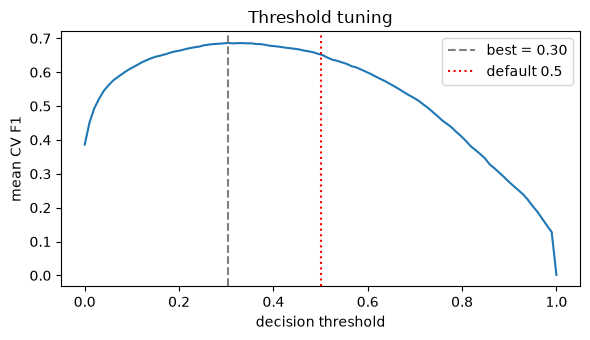

In [33]:
from sklearn.model_selection import FixedThresholdClassifier, TunedThresholdClassifierCV

tuned_lr = TunedThresholdClassifierCV(
    make_pipeline(preprocessor, LogisticRegression(max_iter=1000)),
    scoring="f1", cv=StratifiedKFold(5, shuffle=True, random_state=SEED), store_cv_results=True, n_jobs=-1,
).fit(X_tr, y_tr)

tuned_pred = tuned_lr.predict(X_val)
print(f"best threshold (by CV F1): {tuned_lr.best_threshold_:.3f} | CV F1 at that threshold: {tuned_lr.best_score_:.3f}")
print(f"validation precision {precision_score(y_val, tuned_pred):.3f} | recall {recall_score(y_val, tuned_pred):.3f}")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(tuned_lr.cv_results_["thresholds"], tuned_lr.cv_results_["scores"])
ax.axvline(tuned_lr.best_threshold_, ls="--", color="gray", label=f"best = {tuned_lr.best_threshold_:.2f}")
ax.axvline(0.5, ls=":", color="red", label="default 0.5")
ax.set(xlabel="decision threshold", ylabel="mean CV F1", title="Threshold tuning")
ax.legend()
plt.tight_layout()
plt.show()

**Calibration.** `CalibratedClassifierCV` learns a mapping from raw scores to honest probabilities: `method="sigmoid"` (Platt scaling, 2 parameters, good for small data) or `"isotonic"` (a flexible step function, needs more data). With `cv=5` it fits the model and the mapping on different folds. If a model is already trained, wrap it in `FrozenEstimator` and calibrate on separate data. (`SVC(probability=True)` is deprecated in scikit-learn 1.9 for the same reason: use `CalibratedClassifierCV(SVC(), ensemble=False)`.)

plain                            Brier 0.1016 | mean P 0.239
balanced                         Brier 0.1273 | mean P 0.367
balanced + sigmoid calibration   Brier 0.1021 | mean P 0.238


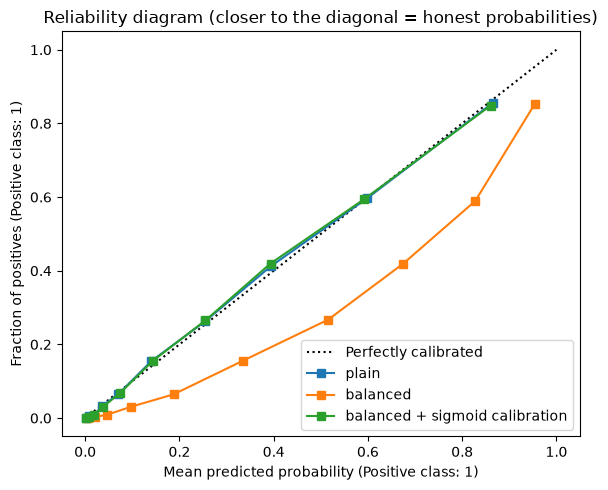

In [34]:
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay

calibrated_balanced = CalibratedClassifierCV(
    make_pipeline(preprocessor, LogisticRegression(max_iter=1000, class_weight="balanced")),
    method="sigmoid", cv=StratifiedKFold(5, shuffle=True, random_state=SEED), n_jobs=-1,
).fit(X_tr, y_tr)

fig, ax = plt.subplots(figsize=(6, 5))
for name, model in [("plain", plain_lr), ("balanced", balanced_lr), ("balanced + sigmoid calibration", calibrated_balanced)]:
    proba = model.predict_proba(X_val)[:, 1]
    CalibrationDisplay.from_predictions(y_val, proba, n_bins=10, strategy="quantile", name=name, ax=ax)
    print(f"{name:32s} Brier {brier_score_loss(y_val, proba):.4f} | mean P {proba.mean():.3f}")
ax.set_title("Reliability diagram (closer to the diagonal = honest probabilities)")
plt.tight_layout()
plt.show()

### ✍️ Your Turn

The business wants to flag anyone with a predicted probability of **at least 0.3**. Wrap the already-fitted `plain_lr` in `FixedThresholdClassifier` with `threshold=0.3`, predict on `X_val`, and store the **number of flagged people** in `n_flagged`.

In [35]:
n_flagged = None  # TODO: FixedThresholdClassifier(plain_lr, threshold=0.3) ...
check("n_flagged", n_flagged, int((plain_lr.predict_proba(X_val)[:, 1] >= 0.3).sum()),
      hint="FixedThresholdClassifier(plain_lr, threshold=0.3).fit(X_tr, y_tr).predict(X_val).sum()")

⏳ n_flagged: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
fixed = FixedThresholdClassifier(plain_lr, threshold=0.3).fit(X_tr, y_tr)
n_flagged = int(fixed.predict(X_val).sum())
check("n_flagged", n_flagged, int((plain_lr.predict_proba(X_val)[:, 1] >= 0.3).sum()))
```

`FixedThresholdClassifier` refits a clone of the model in `fit`. To reuse an already-trained model without refitting, wrap it: `FixedThresholdClassifier(FrozenEstimator(plain_lr), threshold=0.3)`.
</details>

> 💡 **Interview angle:** "How do you handle class imbalance?" — first pick a metric that reflects the business (PR-AUC, recall at a precision, expected cost), keep probabilities calibrated, and **tune the threshold on validation data**. Class weights or resampling can help training, but they shift probabilities, and SMOTE-style oversampling must happen inside the CV training folds only.

## 11. Unsupervised Learning: KMeans, PCA, DBSCAN 🟡

**Unsupervised** = no labels. Two classic jobs:

- **Clustering** — group similar rows. `KMeans` finds *k* round-ish clusters around centroids; `DBSCAN` finds dense regions of any shape and marks isolated points as noise (`-1`).
- **Dimensionality reduction** — `PCA` finds new axes (principal components) that capture the most variance, e.g. to compress 13 features into 2 for plotting.

Both KMeans and PCA work with **distances and variances**, so a feature measured in thousands swamps one measured in fractions. **Scale first.** We use the built-in *wine* dataset: 178 wines, 13 chemical measurements, 3 grape cultivars (we hide the cultivar and only use it to grade the clusters).

In [36]:
from sklearn.cluster import DBSCAN, KMeans
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score

X_wine, y_wine = load_wine(return_X_y=True, as_frame=True)
print("feature scales (std):", X_wine.std().round(2).sort_values().iloc[[0, 1, -2, -1]].to_dict())

for name, model in [("KMeans on raw features", KMeans(n_clusters=3, random_state=SEED)),
                    ("KMeans after scaling", make_pipeline(StandardScaler(), KMeans(n_clusters=3, random_state=SEED)))]:
    clusters = model.fit_predict(X_wine)
    # ARI: 1 = clusters match the hidden cultivars perfectly, ~0 = random
    print(f"{name:24s} adjusted Rand index vs true cultivar: {adjusted_rand_score(y_wine, clusters):.3f}")

feature scales (std): {'nonflavanoid_phenols': 0.12, 'hue': 0.23, 'magnesium': 14.28, 'proline': 314.91}
KMeans on raw features   adjusted Rand index vs true cultivar: 0.352
KMeans after scaling     adjusted Rand index vs true cultivar: 0.897


**Choosing k.** Without labels, use two signals: the **elbow** of the inertia curve (within-cluster squared distance — always decreases, look for the bend) and the **silhouette score** (−1…1, how much closer points are to their own cluster than to the next one; higher is better).

silhouette by k: {2: 0.265, 3: 0.285, 4: 0.254, 5: 0.184, 6: 0.169, 7: 0.173, 8: 0.163} → best k = 3


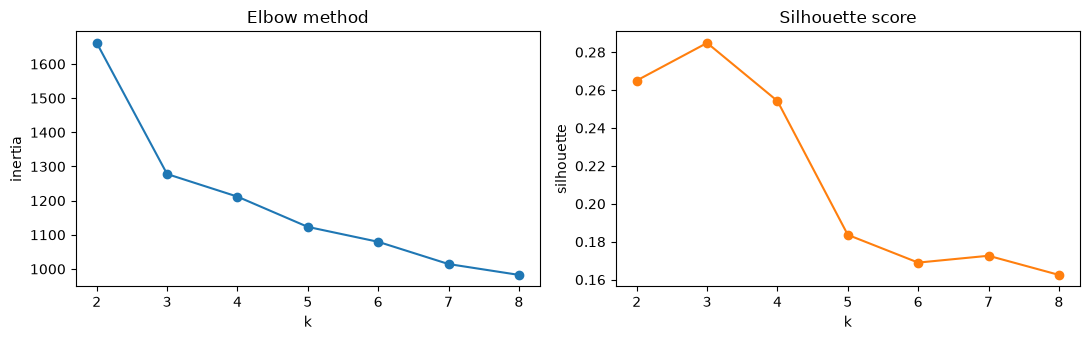

In [37]:
X_wine_scaled = StandardScaler().fit_transform(X_wine)
ks = range(2, 9)
inertias, silhouettes = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=SEED).fit(X_wine_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(float(silhouette_score(X_wine_scaled, km.labels_)))
best_k = list(ks)[int(np.argmax(silhouettes))]
print("silhouette by k:", {k: round(s, 3) for k, s in zip(ks, silhouettes)}, "→ best k =", best_k)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(list(ks), inertias, marker="o")
axes[0].set(xlabel="k", ylabel="inertia", title="Elbow method")
axes[1].plot(list(ks), silhouettes, marker="o", color="tab:orange")
axes[1].set(xlabel="k", ylabel="silhouette", title="Silhouette score")
plt.tight_layout()
plt.show()

❌ PCA on raw features : PC1 explains 99.8% — dominated by 'proline'
✅ PCA after scaling   : PC1 explains 36.2%, PC1+PC2 55.4%


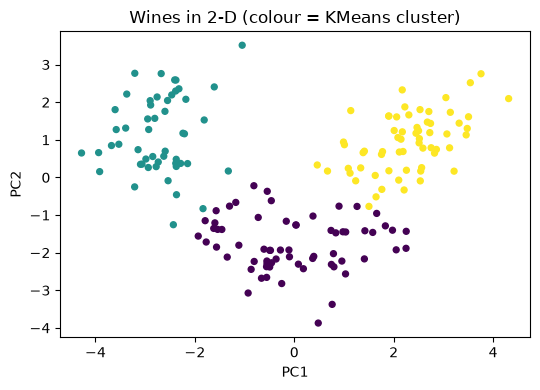

In [38]:
pca_raw = PCA().fit(X_wine)
pca_scaled = make_pipeline(StandardScaler(), PCA()).fit(X_wine)
top_feature = X_wine.columns[np.abs(pca_raw.components_[0]).argmax()]
print(f"❌ PCA on raw features : PC1 explains {pca_raw.explained_variance_ratio_[0]:.1%} — dominated by '{top_feature}'")
print(f"✅ PCA after scaling   : PC1 explains {pca_scaled[-1].explained_variance_ratio_[0]:.1%}, "
      f"PC1+PC2 {pca_scaled[-1].explained_variance_ratio_[:2].sum():.1%}")

coords = pca_scaled.transform(X_wine)[:, :2]
fig, ax = plt.subplots(figsize=(5.5, 4))
scatter = ax.scatter(coords[:, 0], coords[:, 1], c=KMeans(3, random_state=SEED).fit_predict(X_wine_scaled), cmap="viridis", s=18)
ax.set(xlabel="PC1", ylabel="PC2", title="Wines in 2-D (colour = KMeans cluster)")
plt.tight_layout()
plt.show()

**DBSCAN** needs no *k*. It has two knobs: `eps` (neighbourhood radius) and `min_samples`. It shines on non-round shapes — shown here on the **synthetic** "two moons" dataset, which exists exactly to illustrate this.

KMeans ARI 0.248 | DBSCAN ARI 1.000 | DBSCAN clusters 2, noise points 0


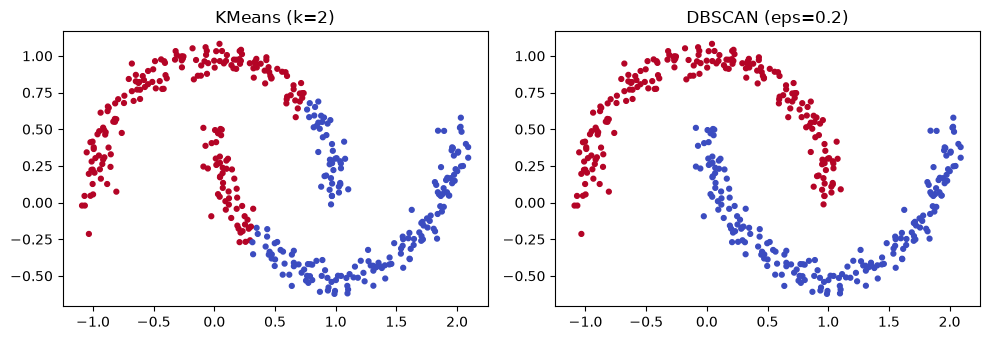

In [39]:
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=400, noise=0.06, random_state=SEED)
km_labels = KMeans(n_clusters=2, random_state=SEED).fit_predict(X_moons)
db_labels = DBSCAN(eps=0.2, min_samples=5).fit_predict(X_moons)
print(f"KMeans ARI {adjusted_rand_score(y_moons, km_labels):.3f} | DBSCAN ARI {adjusted_rand_score(y_moons, db_labels):.3f} "
      f"| DBSCAN clusters {len(set(db_labels) - {-1})}, noise points {(db_labels == -1).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, labels, title in [(axes[0], km_labels, "KMeans (k=2)"), (axes[1], db_labels, "DBSCAN (eps=0.2)")]:
    ax.scatter(X_moons[:, 0], X_moons[:, 1], c=labels, cmap="coolwarm", s=12)
    ax.set_title(title)
plt.tight_layout()
plt.show()

### ✍️ Your Turn

Using `pca_scaled` (StandardScaler → PCA fitted on wine), find the **smallest number of components** whose cumulative explained variance reaches **at least 90%**. Store the integer in `n_components_90`.

In [40]:
n_components_90 = None  # TODO
check("n_components_90", n_components_90, 8, hint="np.cumsum(pca_scaled[-1].explained_variance_ratio_) and np.argmax(cum >= 0.90) + 1")

⏳ n_components_90: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
cumulative = np.cumsum(pca_scaled[-1].explained_variance_ratio_)
n_components_90 = int(np.argmax(cumulative >= 0.90) + 1)
check("n_components_90", n_components_90, 8)
```

Shortcut: `PCA(n_components=0.90)` picks that number for you.
</details>

> 💡 **Interview angle:** "Why standardize before PCA or KMeans?" — both depend on variance/Euclidean distance, so the feature with the largest units dominates. Also: KMeans assumes roughly spherical, similar-size clusters; DBSCAN handles arbitrary shapes and noise but struggles when densities differ, and it has no `predict` for new points.

## 12. Feature Importance 🟡

Two very different questions hide behind "feature importance":

| Method | How it is computed | Pitfalls |
|---|---|---|
| **Impurity-based** (`feature_importances_`, MDI) | how much each feature's splits reduced impurity *while training* | computed on training data; **biased toward high-cardinality / continuous features**, even pure noise |
| **Permutation importance** (`permutation_importance`) | shuffle one column on *held-out* data and measure the score drop | slower; **correlated features share credit** (shuffling one, the model uses its twin), so both look unimportant |

Experiment: add two **pure-noise columns** to Adult — one continuous, one categorical with 100 levels — and see which method is fooled.

In [41]:
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import OrdinalEncoder

def add_noise(frame, seed):
    noise_rng = np.random.default_rng(seed)
    frame = frame.copy()
    frame["random_num"] = noise_rng.normal(size=len(frame))
    frame["random_cat"] = pd.Categorical(noise_rng.integers(0, 100, len(frame)).astype(str))
    return frame

X_fi_tr = add_noise(X_tr.sample(10_000, random_state=SEED), seed=1)
y_fi_tr = y_tr.loc[X_fi_tr.index]
X_fi_val = add_noise(X_val, seed=2)

tree_prep = ColumnTransformer(
    [("cat", make_pipeline(SimpleImputer(strategy="most_frequent"),
                           OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)), categorical_cols)],
    remainder="passthrough", verbose_feature_names_out=False,
).set_output(transform="pandas")
forest = make_pipeline(tree_prep, RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)).fit(X_fi_tr, y_fi_tr)

mdi = pd.Series(forest[-1].feature_importances_, index=forest[:-1].get_feature_names_out())
perm = permutation_importance(forest, X_fi_val, y_val, scoring="roc_auc", n_repeats=5, random_state=SEED, n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=X_fi_val.columns)

importance = pd.DataFrame({"MDI (train)": mdi, "permutation AUC drop (validation)": perm_imp})
importance["MDI rank"] = importance["MDI (train)"].rank(ascending=False).astype(int)
importance["perm rank"] = importance["permutation AUC drop (validation)"].rank(ascending=False).astype(int)
importance.sort_values("MDI (train)", ascending=False)

,MDI (train),permutation AUC drop (validation),MDI rank,perm rank
capital-gain,0.115,5.034e-02,1,1
age,0.110,2.678e-02,2,4
relationship,0.102,3.818e-02,3,2
fnlwgt,0.095,-2.068e-05,4,13
random_num,0.094,-1.312e-04,5,15
education-num,0.088,2.842e-02,6,3
random_cat,0.085,2.256e-04,7,12
marital-status,0.067,2.018e-02,8,5
hours-per-week,0.065,1.691e-02,9,6
occupation,0.051,5.052e-03,10,8


In [42]:
for col in ["random_num", "random_cat"]:
    print(f"{col:11s} MDI rank {importance.loc[col, 'MDI rank']:2d} of {len(importance)} | "
          f"permutation rank {importance.loc[col, 'perm rank']:2d} (AUC drop {importance.loc[col, 'permutation AUC drop (validation)']:+.4f})")

random_num  MDI rank  5 of 16 | permutation rank 15 (AUC drop -0.0001)
random_cat  MDI rank  7 of 16 | permutation rank 12 (AUC drop +0.0002)


In [43]:
# Correlated twins: 'education' and 'education-num' carry the same information
edu = importance.loc[["education", "education-num"], "permutation AUC drop (validation)"]
forest_one_edu = make_pipeline(tree_prep, RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)).fit(
    X_fi_tr.drop(columns="education"), y_fi_tr)
perm_one = permutation_importance(forest_one_edu, X_fi_val.drop(columns="education"), y_val, scoring="roc_auc",
                                  n_repeats=5, random_state=SEED, n_jobs=-1)
edu_num_alone = pd.Series(perm_one.importances_mean, index=X_fi_val.drop(columns="education").columns)["education-num"]
print(f"with both twins : education {edu['education']:.4f}, education-num {edu['education-num']:.4f}")
print(f"twin removed    : education-num {edu_num_alone:.4f}")

with both twins : education 0.0031, education-num 0.0284
twin removed    : education-num 0.0383


> 💡 **Interview angle:** "Can I trust `feature_importances_` from a random forest?" — not blindly: it is measured on training data and favours features with many possible split points. Prefer permutation importance on a validation set, handle correlated features (group them or drop one), and remember importance ≠ causation.

## 13. Custom Transformers 🟡

When no built-in transformer does what you need, write one — and it will work inside `Pipeline`, `GridSearchCV`, and `clone`. The rules:

1. Inherit from `TransformerMixin` (gives `fit_transform`, `set_output`) and `BaseEstimator` (gives `get_params` / `set_params`), in that order.
2. `__init__` **only stores** its arguments under the same names — no validation, no computation.
3. `fit(X, y=None)` learns from data, stores results in attributes ending in `_`, and **returns `self`**.
4. `transform(X)` uses only what `fit` learned.

Example: group rare categories into `"Other"`, where "rare" is learned from the **training data** (a common production need — new, rare values appear all the time).

In [44]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import FunctionTransformer
from sklearn.utils.validation import check_is_fitted


class RareCategoryGrouper(TransformerMixin, BaseEstimator):
    """Replace categories seen in less than `min_share` of training rows with `other_label`."""

    def __init__(self, min_share=0.01, other_label="Other"):
        self.min_share = min_share
        self.other_label = other_label

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.frequent_ = {
            col: set(X[col].value_counts(normalize=True)[lambda s: s >= self.min_share].index)
            for col in X.columns
        }
        self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        return self

    def transform(self, X):
        check_is_fitted(self, "frequent_")
        X = pd.DataFrame(X).astype(object)
        out = {col: X[col].where(X[col].isin(self.frequent_[col]) | X[col].isna(), self.other_label)
               for col in X.columns}
        return pd.DataFrame(out, index=X.index)

    def get_feature_names_out(self, input_features=None):
        return self.feature_names_in_


grouper = RareCategoryGrouper(min_share=0.01).fit(X_tr[["native-country"]])
print("kept countries:", sorted(grouper.frequent_["native-country"]))
print(grouper.transform(X_val[["native-country"]]).value_counts().head(4).to_string())
print("\nclone works:", clone(grouper).get_params())

kept countries: ['Mexico', 'United-States']
native-country
United-States     8792
Other              594
Mexico             195

clone works: {'min_share': 0.01, 'other_label': 'Other'}


In [45]:
# Plug it into a real pipeline, together with a FunctionTransformer for a log feature
custom_prep = ColumnTransformer(
    [
        ("country", make_pipeline(RareCategoryGrouper(min_share=0.01), SimpleImputer(strategy="most_frequent"),
                                  OneHotEncoder(handle_unknown="ignore", sparse_output=False)), ["native-country"]),
        ("money", FunctionTransformer(np.log1p, feature_names_out="one-to-one"), ["capital-gain", "capital-loss"]),
    ],
    remainder="drop",
)
custom_model = make_pipeline(custom_prep, LogisticRegression(max_iter=1000))
grid = GridSearchCV(custom_model, {"columntransformer__country__rarecategorygrouper__min_share": [0.001, 0.05]},
                    cv=search_cv, scoring="roc_auc").fit(X_zoo, y_zoo)
print("grid search can tune our transformer:", grid.best_params_, f"CV AUC {grid.best_score_:.3f}")

grid search can tune our transformer: {'columntransformer__country__rarecategorygrouper__min_share': 0.001} CV AUC 0.629


### ✍️ Your Turn

Complete `MaxAbsDivider`: in `fit`, learn the **maximum absolute value of each column** into `max_abs_` and return `self`; in `transform`, divide by it. The checker compares your output with scikit-learn's `MaxAbsScaler`.

In [46]:
from sklearn.preprocessing import MaxAbsScaler

class MaxAbsDivider(TransformerMixin, BaseEstimator):
    def fit(self, X, y=None):
        # TODO: learn self.max_abs_ and return self
        return None

    def transform(self, X):
        # TODO: divide X by the learned values
        return None


X_demo = np.array([[1.0, -8.0], [-4.0, 2.0], [2.0, 4.0]])
fitted_divider = MaxAbsDivider().fit(X_demo)
check("max_abs_divider", None if fitted_divider is None else fitted_divider.transform(X_demo),
      MaxAbsScaler().fit_transform(X_demo), hint="self.max_abs_ = np.abs(X).max(axis=0); return self")

⏳ max_abs_divider: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
from sklearn.preprocessing import MaxAbsScaler

class MaxAbsDivider(TransformerMixin, BaseEstimator):
    def fit(self, X, y=None):
        self.max_abs_ = np.abs(np.asarray(X, dtype=float)).max(axis=0)
        return self

    def transform(self, X):
        check_is_fitted(self, "max_abs_")
        return np.asarray(X, dtype=float) / self.max_abs_


X_demo = np.array([[1.0, -8.0], [-4.0, 2.0], [2.0, 4.0]])
fitted_divider = MaxAbsDivider().fit(X_demo)
check("max_abs_divider", fitted_divider.transform(X_demo), MaxAbsScaler().fit_transform(X_demo))
```

Forgetting `return self` is the classic bug: `MaxAbsDivider().fit(X).transform(X)` then fails with `'NoneType' object has no attribute 'transform'`. (The real `MaxAbsScaler` also guards against dividing by a zero column.)
</details>

> 💡 **Interview angle:** "Why must `__init__` not modify its parameters?" — `clone` and `set_params` rebuild estimators from `get_params()`; if `__init__` transforms or validates values, a cloned estimator inside `GridSearchCV` silently differs from the one you configured. Do all work in `fit`.

## 14. Persistence and Reproducibility 🟢

**Saving a model.** `joblib.dump` / `joblib.load` pickles the whole fitted pipeline — preprocessing included — so production applies exactly the same steps. Two warnings:

1. 🔓 **Never load a pickle/joblib file you do not trust.** Unpickling can execute arbitrary code (demo below). For sharing models, **skops** (`skops.io`) stores models in a format that lists unknown types for you to approve before loading.
2. 📌 Load with the **same scikit-learn version** you saved with. Other versions raise `InconsistentVersionWarning` and may behave differently; store the version next to the model.

In [47]:
import json

model_path = OUTPUT_DIR / "adult_logreg.joblib"
joblib.dump(plain_lr, model_path)
(OUTPUT_DIR / "adult_logreg.meta.json").write_text(json.dumps({"sklearn": sklearn.__version__, "features": list(X_tr.columns)}))
reloaded = joblib.load(model_path)
print(f"saved {model_path.stat().st_size / 1024:.0f} KB | identical probabilities after reload:",
      np.array_equal(reloaded.predict_proba(X_val), plain_lr.predict_proba(X_val)))

saved 14 KB | identical probabilities after reload: True


In [48]:
# Why untrusted pickles are dangerous: loading runs whatever __reduce__ says. (This one only prints.)
class NotAModel:
    def __reduce__(self):
        return (print, ("⚠️  this code ran just by LOADING the file — a real attacker could run anything",))


joblib.dump(NotAModel(), OUTPUT_DIR / "suspicious.joblib")
_ = joblib.load(OUTPUT_DIR / "suspicious.joblib")

⚠️  this code ran just by LOADING the file — a real attacker could run anything


In [49]:
import skops.io as sio

skops_path = OUTPUT_DIR / "adult_logreg.skops"
sio.dump(plain_lr, skops_path)
unknown = sio.get_untrusted_types(file=skops_path)
print("types skops asks you to review before loading:", unknown)
safe_model = sio.load(skops_path, trusted=unknown)      # only after you have reviewed the list!
print("skops round-trip identical:", np.array_equal(safe_model.predict_proba(X_val), plain_lr.predict_proba(X_val)))

types skops asks you to review before loading: ['numpy.dtype', 'sklearn.compose._column_transformer.make_column_selector']
skops round-trip identical: True


**Reproducibility.** Anything random — shuffling in CV, bootstrap samples in a forest, random search — is controlled by `random_state`:

- `random_state=None` (the default): different results every run.
- `random_state=42` (an int): identical results every run. Use this for experiments and tests.
- Also fix: the data split, library versions, and the order of rows.

In [50]:
def forest_auc(random_state):
    rf = make_pipeline(tree_prep, RandomForestClassifier(n_estimators=50, random_state=random_state, n_jobs=-1))
    rf.fit(X_zoo, y_zoo)
    return roc_auc_score(y_val, rf.predict_proba(X_val)[:, 1])


print("random_state=None:", [round(forest_auc(None), 5) for _ in range(2)])
print("random_state=7   :", [round(forest_auc(7), 5) for _ in range(2)])

random_state=None: [0.92888, 0.93236]


random_state=7   : [0.93093, 0.93093]


> 💡 **Interview angle:** "How do you ship a scikit-learn model safely?" — save the *whole pipeline* (not just the model), pin and record library versions, prefer skops or a server-side-only artefact store for untrusted sources, and test that the reloaded model reproduces predictions on a fixed sample before deploying.

## 🔧 Build It From Scratch

`Pipeline` and `GridSearchCV` feel like magic, but together they are only ~40 lines of plain Python. Building them yourself is the best way to *really* understand why pipelines prevent leakage — and "implement cross-validated grid search" is a common coding-interview prompt.

**The plan**
1. `MiniPipeline`: `fit` calls `fit_transform` on each transformer in order (on the training data only), then `fit` on the final model; `predict` only calls `transform`.
2. `mini_grid_search`: for every combination of hyperparameters, for every fold, **clone** the pipeline, set the parameters, fit on the training part, score on the validation part; average; keep the best.
3. `assert` that the scores and best parameters match scikit-learn's `GridSearchCV` exactly.

We reuse scikit-learn's fold *indices* (`StratifiedKFold`) so both implementations see identical splits, and `clone` for fresh copies — everything else is ours.

In [51]:
import itertools


class MiniPipeline:
    """A list of (name, estimator) steps: transformers first, a predictor last."""

    def __init__(self, steps):
        self.steps = steps

    def set_params(self, **params):
        named = dict(self.steps)
        for key, value in params.items():
            step_name, param = key.split("__", 1)          # "knn__n_neighbors" → ("knn", "n_neighbors")
            named[step_name].set_params(**{param: value})
        return self

    def fit(self, X, y):
        Xt = X
        for _, transformer in self.steps[:-1]:
            Xt = transformer.fit_transform(Xt, y)          # learns from TRAINING data only
        self.steps[-1][1].fit(Xt, y)
        return self

    def predict(self, X):
        Xt = X
        for _, transformer in self.steps[:-1]:
            Xt = transformer.transform(Xt)                 # never re-fit on new data
        return self.steps[-1][1].predict(Xt)

    def score(self, X, y):
        return float(np.mean(self.predict(X) == np.asarray(y)))


def mini_grid_search(steps, param_grid, X, y, cv):
    keys = sorted(param_grid)                              # GridSearchCV also iterates keys in sorted order
    X, y = np.asarray(X), np.asarray(y)
    folds = list(cv.split(X, y))
    results = []
    for values in itertools.product(*(param_grid[k] for k in keys)):
        params = dict(zip(keys, values))
        fold_scores = []
        for train_idx, val_idx in folds:
            pipe = MiniPipeline([(name, clone(est)) for name, est in steps]).set_params(**params)
            pipe.fit(X[train_idx], y[train_idx])
            fold_scores.append(pipe.score(X[val_idx], y[val_idx]))
        results.append({"params": params, "fold_scores": fold_scores, "mean": float(np.mean(fold_scores))})
    best = max(results, key=lambda r: r["mean"])           # max keeps the FIRST best on ties, like sklearn
    return best["params"], results

In [52]:
from sklearn.pipeline import Pipeline

grid = {"knn__n_neighbors": [1, 5, 15, 31], "knn__weights": ["uniform", "distance"], "scale__with_std": [True, False]}
steps = [("scale", StandardScaler()), ("knn", KNeighborsClassifier())]
scratch_cv = StratifiedKFold(5, shuffle=True, random_state=SEED)

start = time.perf_counter()
our_best, our_results = mini_grid_search(steps, grid, X_bc, y_bc, scratch_cv)
ours_s = time.perf_counter() - start

sk_search = GridSearchCV(Pipeline(steps), grid, cv=scratch_cv).fit(X_bc, y_bc)

sk_means = {tuple(sorted(p.items())): m for p, m in zip(sk_search.cv_results_["params"], sk_search.cv_results_["mean_test_score"])}
for r in our_results:
    assert np.isclose(r["mean"], sk_means[tuple(sorted(r["params"].items()))])
assert our_best == sk_search.best_params_
fold0 = [r["fold_scores"][0] for r in our_results]
assert np.allclose(fold0, sk_search.cv_results_["split0_test_score"])

print(f"✅ all {len(our_results)} candidates match GridSearchCV (means and per-fold scores) | ours took {ours_s:.2f}s")
print("best params:", our_best, f"| CV accuracy {max(r['mean'] for r in our_results):.4f}")

✅ all 16 candidates match GridSearchCV (means and per-fold scores) | ours took 0.27s
best params: {'knn__n_neighbors': 5, 'knn__weights': 'uniform', 'scale__with_std': True} | CV accuracy 0.9631


What scikit-learn adds on top: parallel fits (`n_jobs`), many metrics at once, error handling (`error_score`), refitting the winner, metadata routing, and `cv_results_` with timings and ranks. The *core idea* — clone, fit on train folds, score on validation folds — is exactly what you just wrote.

## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Calling `fit_transform` on the test data

The test set gets re-scaled with *its own* statistics, so the same person gets a different feature vector depending on who else is in the batch.

In [53]:
num_cols = ["age", "education-num", "hours-per-week", "capital-gain"]
older = X_val[X_val["age"] >= 50][num_cols]                 # a batch that is not like the training data
scaler = StandardScaler().fit(X_tr[num_cols])

wrong = StandardScaler().fit_transform(older)                # ❌ re-fit on the new batch
right = scaler.transform(older)                              # ✅ reuse training statistics
print(f"❌ mean scaled age of the 50+ batch: {wrong[:, 0].mean():+.2f}  (looks 'average' — the shift is erased)")
print(f"✅ mean scaled age of the 50+ batch: {right[:, 0].mean():+.2f}  (correctly older than training)")

lr_num = LogisticRegression(max_iter=1000).fit(scaler.transform(X_tr[num_cols]), y_tr)
changed = (lr_num.predict(wrong) != lr_num.predict(right)).mean()
print(f"→ {changed:.1%} of predictions flip just because of the wrong scaling")

❌ mean scaled age of the 50+ batch: +0.00  (looks 'average' — the shift is erased)
✅ mean scaled age of the 50+ batch: +1.48  (correctly older than training)
→ 14.7% of predictions flip just because of the wrong scaling


### ❌ Pitfall 2 — Using `SelectFromModel` with an unfitted model outside a pipeline

In [54]:
from sklearn.feature_selection import SelectFromModel

X_bc_array = X_bc.to_numpy()
try:
    SelectFromModel(RandomForestClassifier(random_state=SEED)).transform(X_bc_array)   # ❌ nothing was fitted
except (NotFittedError, ValueError) as err:
    print(f"❌ {type(err).__name__}:", str(err)[:150], "…")

# ✅ Put selection inside the pipeline: it is fit on each training fold, then transform-only on validation
selector_pipe = make_pipeline(SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=SEED)),
                              StandardScaler(), LogisticRegression())
print(f"✅ CV accuracy with in-pipeline selection: {cross_val_score(selector_pipe, X_bc_array, y_bc, cv=cv5).mean():.3f}")
print("   (if the forest is already trained, SelectFromModel(fitted_forest, prefit=True) also works — but "
      "then it must have been trained on training data only)")

❌ ValueError: when `importance_getter=='auto'`, the underlying estimator RandomForestClassifier should have `coef_` or `feature_importances_` attribute. Either pass …


✅ CV accuracy with in-pipeline selection: 0.954
   (if the forest is already trained, SelectFromModel(fitted_forest, prefit=True) also works — but then it must have been trained on training data only)


### ❌ Pitfall 3 — Assuming ensembles "handle scaling internally"

A stacking ensemble is only as good as its base models, and SVMs / kNN still need scaled inputs. Nothing inside `StackingClassifier` scales for you.

In [55]:
from sklearn.ensemble import StackingClassifier

base_unscaled = [("svc", SVC()), ("knn", KNeighborsClassifier())]
base_scaled = [("svc", make_pipeline(StandardScaler(), SVC())), ("knn", make_pipeline(StandardScaler(), KNeighborsClassifier()))]
for label, base in [("❌ unscaled base models", base_unscaled), ("✅ scaled base models  ", base_scaled)]:
    stack = StackingClassifier(base, final_estimator=LogisticRegression(), cv=5)
    print(f"{label}: CV accuracy {cross_val_score(stack, X_bc, y_bc, cv=cv5, n_jobs=-1).mean():.3f}")

❌ unscaled base models: CV accuracy 0.932


✅ scaled base models  : CV accuracy 0.972


### ❌ Pitfall 4 — Running PCA on unscaled features

In [56]:
pca_wrong = PCA(n_components=2).fit(X_wine)
pca_right = make_pipeline(StandardScaler(), PCA(n_components=2)).fit(X_wine)
print(f"❌ unscaled: PC1 = {pca_wrong.explained_variance_ratio_[0]:.1%} of variance, almost entirely "
      f"'{X_wine.columns[np.abs(pca_wrong.components_[0]).argmax()]}' (values in the hundreds–thousands)")
weights = pd.Series(np.abs(pca_right[-1].components_[0]), index=X_wine.columns)
print(f"✅ scaled  : PC1 = {pca_right[-1].explained_variance_ratio_[0]:.1%}; largest weight is only "
      f"{weights.max() / weights.sum():.0%} of the total — many features contribute")

❌ unscaled: PC1 = 99.8% of variance, almost entirely 'proline' (values in the hundreds–thousands)
✅ scaled  : PC1 = 36.2%; largest weight is only 13% of the total — many features contribute


### ❌ Pitfall 5 — Using `hash()` to make seeds

Python randomizes string hashes **per process** (for security), so `hash("age") % 100` changes every time you restart. Experiments seeded this way are not reproducible.

In [57]:
import os
import subprocess
import zlib

env = {k: v for k, v in os.environ.items() if k != "PYTHONHASHSEED"}
runs = [subprocess.run([sys.executable, "-c", "print(hash('age') % 100)"], capture_output=True, text=True, env=env).stdout.strip()
        for _ in range(3)]
print("❌ hash('age') % 100 in three fresh Python processes:", runs, "→", "different" if len(set(runs)) > 1 else "same (by luck)")
print("✅ zlib.crc32(b'age') % 100 is stable across processes:", zlib.crc32(b"age") % 100, "— or simply use a fixed integer seed")

❌ hash('age') % 100 in three fresh Python processes: ['20', '8', '58'] → different
✅ zlib.crc32(b'age') % 100 is stable across processes: 78 — or simply use a fixed integer seed


### ❌ Pitfall 6 — `OneHotEncoder` crashing on a category it has never seen

In [58]:
train_colors = pd.DataFrame({"color": ["red", "blue", "red"]})
live_colors = pd.DataFrame({"color": ["blue", "green"]})         # 'green' never appeared in training

try:
    OneHotEncoder().fit(train_colors).transform(live_colors)       # ❌ default handle_unknown="error"
except ValueError as err:
    print("❌ ValueError:", err)

safe = OneHotEncoder(handle_unknown="ignore", sparse_output=False).fit(train_colors)
print("✅ handle_unknown='ignore' → unseen category becomes all zeros:\n", safe.transform(live_colors))

❌ ValueError: Found unknown categories ['green'] in column 0 during transform
✅ handle_unknown='ignore' → unseen category becomes all zeros:
 [[1. 0.]
 [0. 0.]]


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — Scale before kNN
Build a pipeline `StandardScaler → KNeighborsClassifier()` (default k=5) and compute its mean 5-fold CV accuracy on `X_bc`, `y_bc` using `cv=StratifiedKFold(5, shuffle=True, random_state=0)`. Store it in `knn_cv_accuracy`.

In [59]:
knn_cv_accuracy = None  # TODO
check("knn_cv_accuracy", knn_cv_accuracy, 0.96488, atol=1e-4,
      hint="cross_val_score(make_pipeline(StandardScaler(), KNeighborsClassifier()), X_bc, y_bc, cv=StratifiedKFold(5, shuffle=True, random_state=0)).mean()")

⏳ knn_cv_accuracy: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
knn_cv_accuracy = cross_val_score(
    make_pipeline(StandardScaler(), KNeighborsClassifier()), X_bc, y_bc,
    cv=StratifiedKFold(5, shuffle=True, random_state=0),
).mean()
check("knn_cv_accuracy", knn_cv_accuracy, 0.96488, atol=1e-4)
```

Without the scaler the same model scores about 0.93: features like `mean area` (hundreds) dominate the distances.
</details>

### 🟢 Exercise 2 — Unknown categories at prediction time
Fit a `OneHotEncoder(handle_unknown="ignore", sparse_output=False)` on `cities_train` and transform `cities_live`. Store the resulting array in `encoded_live`.

In [60]:
cities_train = pd.DataFrame({"city": ["Paris", "Tokyo", "Paris"]})
cities_live = pd.DataFrame({"city": ["Paris", "Berlin"]})
encoded_live = None  # TODO
check("encoded_live", encoded_live, [[1.0, 0.0], [0.0, 0.0]], hint="Columns are sorted categories: Paris, Tokyo. Berlin is unknown → all zeros.")

⏳ encoded_live: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
cities_train = pd.DataFrame({"city": ["Paris", "Tokyo", "Paris"]})
cities_live = pd.DataFrame({"city": ["Paris", "Berlin"]})
encoded_live = OneHotEncoder(handle_unknown="ignore", sparse_output=False).fit(cities_train).transform(cities_live)
check("encoded_live", encoded_live, [[1.0, 0.0], [0.0, 0.0]])
```
</details>

### 🟢 Exercise 3 — Precision and recall by hand
From `y_true_ex` and `y_pred_ex`, compute the confusion-matrix counts yourself and return a dict `{"precision": ..., "recall": ...}` for the positive class (1). No `sklearn.metrics` allowed.

In [61]:
y_true_ex = np.array([1, 0, 1, 1, 0, 0, 1, 0, 1, 0])
y_pred_ex = np.array([1, 0, 0, 1, 1, 0, 1, 0, 0, 0])
pr_dict = None  # TODO
check("pr_dict", pr_dict, {"precision": 0.75, "recall": 0.6}, hint="TP = ((y_pred == 1) & (y_true == 1)).sum(); precision = TP / predicted positives")

⏳ pr_dict: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
y_true_ex = np.array([1, 0, 1, 1, 0, 0, 1, 0, 1, 0])
y_pred_ex = np.array([1, 0, 0, 1, 1, 0, 1, 0, 0, 0])
tp = int(((y_pred_ex == 1) & (y_true_ex == 1)).sum())   # 3
fp = int(((y_pred_ex == 1) & (y_true_ex == 0)).sum())   # 1
fn = int(((y_pred_ex == 0) & (y_true_ex == 1)).sum())   # 2
pr_dict = {"precision": tp / (tp + fp), "recall": tp / (tp + fn)}
check("pr_dict", pr_dict, {"precision": 0.75, "recall": 0.6})
```
</details>

### 🟡 Exercise 4 — A percentile-clipping transformer
Complete `PercentileClipper`: `fit` learns each column's `lower` and `upper` percentiles (defaults 5 and 95) into `low_` and `high_`; `transform` clips values to that range. The checker fits on `X_fit` and transforms `X_new`.

In [62]:
class PercentileClipper(TransformerMixin, BaseEstimator):
    def __init__(self, lower=5, upper=95):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        # TODO: set self.low_ and self.high_ with np.percentile(..., axis=0), then return self
        return self

    def transform(self, X):
        # TODO: return np.clip(...)
        return None


X_fit = np.column_stack([np.arange(101.0), np.arange(0.0, 202.0, 2.0)])     # columns 0..100 and 0..200
X_new = np.array([[-50.0, 500.0], [50.0, 100.0]])
check("percentile_clipper", PercentileClipper().fit(X_fit).transform(X_new), [[5.0, 190.0], [50.0, 100.0]],
      hint="np.percentile(X, self.lower, axis=0) gives one value per column; np.clip(X, self.low_, self.high_) broadcasts.")

⏳ percentile_clipper: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
class PercentileClipper(TransformerMixin, BaseEstimator):
    def __init__(self, lower=5, upper=95):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.low_ = np.percentile(X, self.lower, axis=0)
        self.high_ = np.percentile(X, self.upper, axis=0)
        return self

    def transform(self, X):
        check_is_fitted(self, ["low_", "high_"])
        return np.clip(np.asarray(X, dtype=float), self.low_, self.high_)


X_fit = np.column_stack([np.arange(101.0), np.arange(0.0, 202.0, 2.0)])
X_new = np.array([[-50.0, 500.0], [50.0, 100.0]])
check("percentile_clipper", PercentileClipper().fit(X_fit).transform(X_new), [[5.0, 190.0], [50.0, 100.0]])
```

Because the limits are learned in `fit`, putting this in a pipeline means they come from the training folds only.
</details>

### 🟡 Exercise 5 — Pick a threshold for a recall target
A screening team needs **recall ≥ 0.85**. Among thresholds that achieve it, pick the one with the **highest precision**. Use `precision_recall_curve(y_val_ex, proba_ex)` and store the threshold (a float) in `chosen_threshold`.

In [63]:
from sklearn.metrics import precision_recall_curve

y_val_ex = np.array([0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1])
proba_ex = np.array([0.1, 0.35, 0.4, 0.8, 0.45, 0.65, 0.3, 0.2, 0.9, 0.55, 0.6, 0.7])
chosen_threshold = None  # TODO
check("chosen_threshold", chosen_threshold, 0.4,
      hint="precision, recall, thresholds = precision_recall_curve(...); drop the last precision/recall value so lengths match thresholds.")

⏳ chosen_threshold: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
from sklearn.metrics import precision_recall_curve

y_val_ex = np.array([0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1])
proba_ex = np.array([0.1, 0.35, 0.4, 0.8, 0.45, 0.65, 0.3, 0.2, 0.9, 0.55, 0.6, 0.7])
precision, recall, thresholds = precision_recall_curve(y_val_ex, proba_ex)
precision, recall = precision[:-1], recall[:-1]          # the last point has no threshold
ok = recall >= 0.85
chosen_threshold = float(thresholds[ok][np.argmax(precision[ok])])
check("chosen_threshold", chosen_threshold, 0.4)
```

In a real project, do this on validation data (or let `TunedThresholdClassifierCV` do it with cross-validation) — never on the test set.
</details>

### 🔴 Exercise 6 — Find and fix the target-encoding leak (interview-style)

A teammate says: *"`customer_zip` is a super predictive feature — AUC 0.86!"* Their code is below. The zip codes are actually **random noise** we attached to real Adult rows, so an honest AUC should be ≈ 0.5.

Rewrite the evaluation so the encoding is learned **inside** cross-validation: a pipeline `TargetEncoder(cv=StratifiedKFold(5, shuffle=True, random_state=0)) → LogisticRegression()` evaluated with the same `zip_cv` on the raw `zips` column. Store the mean CV ROC-AUC in `honest_zip_auc`.

In [64]:
zip_rows = X_adult.sample(4000, random_state=0).index
y_zip = y_adult.loc[zip_rows]
zips = pd.DataFrame({"customer_zip": np.random.default_rng(7).integers(0, 1500, len(zip_rows)).astype(str)}, index=zip_rows)
zip_cv = StratifiedKFold(5, shuffle=True, random_state=0)

# The teammate's leaky version: average income per zip computed on ALL rows, then cross-validated
zip_rate = zips["customer_zip"].map(y_zip.groupby(zips["customer_zip"]).mean()).to_frame("zip_rate")
leaky_zip_auc = cross_val_score(LogisticRegression(), zip_rate, y_zip, cv=zip_cv, scoring="roc_auc").mean()
print(f"❌ leaky AUC: {leaky_zip_auc:.3f} (most zips have 1–3 people, so the 'rate' is basically their own label)")

❌ leaky AUC: 0.862 (most zips have 1–3 people, so the 'rate' is basically their own label)


In [65]:
honest_zip_auc = None  # TODO
check("honest_zip_auc", honest_zip_auc, 0.49907, atol=1e-4,
      hint="cross_val_score(make_pipeline(TargetEncoder(cv=StratifiedKFold(5, shuffle=True, random_state=0)), LogisticRegression()), zips, y_zip, cv=zip_cv, scoring='roc_auc').mean()")

⏳ honest_zip_auc: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
honest_pipe = make_pipeline(
    TargetEncoder(cv=StratifiedKFold(5, shuffle=True, random_state=0)),   # cross-fitted inside each training fold
    LogisticRegression(),
)
honest_zip_auc = cross_val_score(honest_pipe, zips, y_zip, cv=zip_cv, scoring="roc_auc").mean()
check("honest_zip_auc", honest_zip_auc, 0.49907, atol=1e-4)
```

**What to say in the interview:** the leak has two layers. (1) The encoding was computed on all rows, so validation labels were baked into the feature. (2) Even within training data, a plain mean encoding lets each row see its own label; `TargetEncoder.fit_transform` cross-fits to prevent that, and smoothing pulls rare categories toward the global mean. An AUC jump from a high-cardinality ID-like column is a classic leakage smell.
</details>

## 🚀 Mini Project: Adult Income Campaign Targeting

**Business goal.** A bank is launching a premium financial-planning product. Marketing will phone people predicted to earn **more than $50K**. From past campaigns:

- calling a real high earner brings **+$40** expected margin (true positive)
- calling anyone else wastes **$10** of agent time (false positive)
- not calling someone costs nothing

So the goal is **maximum profit per person in the list**, not accuracy. If probabilities are calibrated, theory says: call when $40·p − 10·(1−p) > 0$, i.e. when $p > 10 / 50 = 0.2$.

**Steps:** EDA summary → split (test locked) → preprocessing pipelines → CV comparison of 3 models → tuned search → calibration → threshold tuned for profit → one final test evaluation → save, reload, verify.

⚖️ **Responsible-use note:** census data contains sensitive attributes. We exclude `race` and `sex` from the features (and `fnlwgt`, a census sampling weight, plus `education`, a text duplicate of `education-num`), and we still **audit** outcomes by `sex` at the end, because other features can act as proxies.

### Step 1 — EDA summary

In [66]:
eda = pd.DataFrame({
    "dtype": X_adult.dtypes.astype(str),
    "missing %": (X_adult.isna().mean() * 100).round(2),
    "unique values": X_adult.nunique(),
})
print(f"rows {len(X_adult):,} | positive rate {y_adult.mean():.1%}")
eda.T

rows 48,842 | positive rate 23.9%


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
dtype,int64,category,int64,category,int64,category,category,category,category,category,int64,int64,int64,category
missing %,0.0,5.73,0.0,0.0,0.0,0.0,5.75,0.0,0.0,0.0,0.0,0.0,0.0,1.75
unique values,74,8,28523,16,16,7,14,6,5,2,123,99,96,41


                        mean   size
marital-status                     
Married-civ-spouse     0.446  22379
Married-AF-spouse      0.378     37
Divorced               0.101   6633
Married-spouse-absent  0.092    628
Widowed                0.084   1518
Separated              0.065   1530
Never-married          0.045  16117

>50K rate with a bachelor's or higher: 48.1% vs without: 16.0%
>50K rate with any capital gain: 61.7% (8.3% of people) vs none: 20.5%


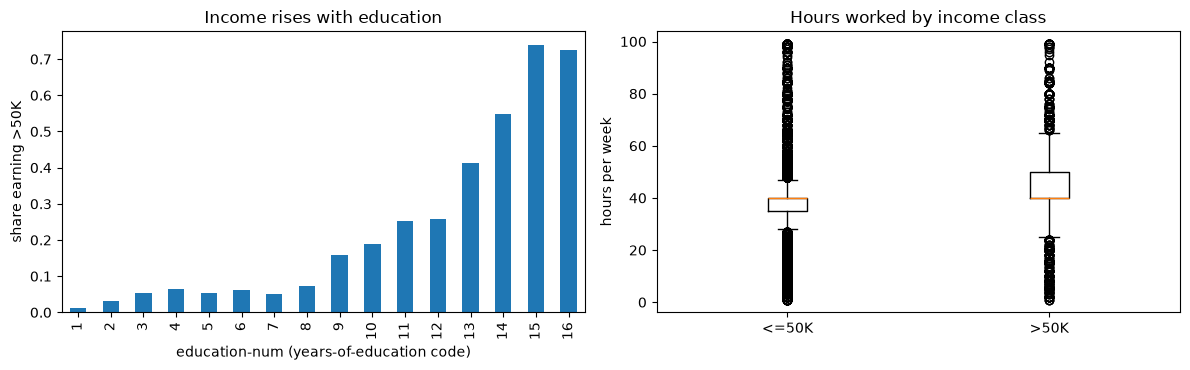

In [67]:
rate_by_marital = y_adult.groupby(X_adult["marital-status"], observed=True).agg(["mean", "size"]).sort_values("mean", ascending=False)
print(rate_by_marital.round(3).to_string())

degree = X_adult["education-num"] >= 13                       # bachelor's degree or higher
print(f"\n>50K rate with a bachelor's or higher: {y_adult[degree].mean():.1%} vs without: {y_adult[~degree].mean():.1%}")
has_gain = X_adult["capital-gain"] > 0
print(f">50K rate with any capital gain: {y_adult[has_gain].mean():.1%} ({has_gain.mean():.1%} of people) vs none: {y_adult[~has_gain].mean():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
y_adult.groupby(X_adult["education-num"]).mean().plot.bar(ax=axes[0], color="tab:blue")
axes[0].set(xlabel="education-num (years-of-education code)", ylabel="share earning >50K", title="Income rises with education")
axes[1].boxplot([X_adult.loc[y_adult == 0, "hours-per-week"], X_adult.loc[y_adult == 1, "hours-per-week"]],
                tick_labels=["<=50K", ">50K"])
axes[1].set(ylabel="hours per week", title="Hours worked by income class")
plt.tight_layout()
plt.show()

### Step 2 — Split once, lock the test set

In [68]:
DROP = ["fnlwgt", "education", "race", "sex"]
FEATURES = [c for c in X_adult.columns if c not in DROP]

Xp_train, Xp_test, yp_train, yp_test = train_test_split(
    X_adult[FEATURES], y_adult, test_size=0.2, stratify=y_adult, random_state=SEED
)
project_cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
print(f"features ({len(FEATURES)}): {FEATURES}")
print(f"train {Xp_train.shape} | test {Xp_test.shape} 🔒 (used once, in Step 8)")

features (10): ['age', 'workclass', 'education-num', 'marital-status', 'occupation', 'relationship', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']
train (39073, 10) | test (9769, 10) 🔒 (used once, in Step 8)


### Step 3 — Preprocessing pipelines

Each model family gets the preprocessing it needs, always inside a pipeline:
- **Logistic regression:** impute → scale numbers; impute → one-hot categories.
- **Random forest:** impute → ordinal-encode categories (trees don't need one-hot or scaling).
- **HistGradientBoosting:** nothing — it reads pandas categories and missing values natively.

In [69]:
project_models = {
    "LogisticRegression": make_pipeline(clone(preprocessor), LogisticRegression(max_iter=1000)),
    "RandomForest": make_pipeline(clone(tree_prep), RandomForestClassifier(n_estimators=300, min_samples_leaf=3,
                                                                         random_state=SEED, n_jobs=-1)),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=SEED),
}
check_hgb = HistGradientBoostingClassifier(random_state=SEED).fit(Xp_train.head(2000), yp_train.head(2000))
print("HGB treats as categorical:", [f for f, is_cat in zip(FEATURES, check_hgb.is_categorical_) if is_cat])

HGB treats as categorical: ['workclass', 'marital-status', 'occupation', 'relationship', 'native-country']


### Step 4 — Cross-validated comparison of 3 models

In [70]:
metrics = {"roc_auc": "roc_auc", "avg_precision": "average_precision", "log_loss": "neg_log_loss", "brier": "neg_brier_score"}
cmp_rows = []
for name, model in project_models.items():
    res = cross_validate(model, Xp_train, yp_train, cv=project_cv, scoring=metrics, n_jobs=5)
    cmp_rows.append({"model": name, "ROC-AUC": res["test_roc_auc"].mean(), "avg precision": res["test_avg_precision"].mean(),
                     "log loss": -res["test_log_loss"].mean(), "Brier": -res["test_brier"].mean(),
                     "fit s": res["fit_time"].mean()})
comparison = pd.DataFrame(cmp_rows).set_index("model").sort_values("log loss")
winner = comparison.index[0]
print(f"lowest CV log loss: {winner}")
comparison

lowest CV log loss: HistGradientBoosting


,ROC-AUC,avg precision,log loss,Brier,fit s
model,,,,,
HistGradientBoosting,0.928,0.827,0.278,0.088,2.306
RandomForest,0.916,0.804,0.300,0.095,2.037
LogisticRegression,0.904,0.762,0.322,0.103,0.293


### Step 5 — Tune the winner with randomized search

We optimise **log loss** because the business decision depends on good *probabilities*, not only on ranking.

In [71]:
hgb_space = {
    "learning_rate": loguniform(0.02, 0.3),
    "max_leaf_nodes": randint(8, 128),
    "min_samples_leaf": randint(10, 200),
    "l2_regularization": loguniform(1e-3, 10),
    "max_features": [0.5, 0.75, 1.0],
}
start = time.perf_counter()
tuner = RandomizedSearchCV(HistGradientBoostingClassifier(random_state=SEED), hgb_space, n_iter=20,
                           scoring="neg_log_loss", cv=project_cv, n_jobs=-1, random_state=SEED).fit(Xp_train, yp_train)
default_hgb_loss = comparison.loc["HistGradientBoosting", "log loss"]
tuned_loss = -tuner.best_score_
print(f"search took {time.perf_counter() - start:.0f}s")
print("best params:", {k: round(float(v), 4) if isinstance(v, float) else v for k, v in tuner.best_params_.items()})
print(f"CV log loss (same folds): default HGB {default_hgb_loss:.4f} | tuned {tuned_loss:.4f}")

# Keep the tuned model only if it actually beats the defaults on the same CV folds
if tuned_loss < default_hgb_loss:
    best_hgb = HistGradientBoostingClassifier(random_state=SEED, **tuner.best_params_)
    print("→ using the tuned hyperparameters")
else:
    best_hgb = HistGradientBoostingClassifier(random_state=SEED)
    print("→ tuning did not beat the defaults, so we keep the default HistGradientBoosting (a real, common outcome)")

search took 14s
best params: {'l2_regularization': 0.7004, 'learning_rate': 0.17, 'max_features': 1.0, 'max_leaf_nodes': 12, 'min_samples_leaf': 50}
CV log loss (same folds): default HGB 0.2777 | tuned 0.2790
→ tuning did not beat the defaults, so we keep the default HistGradientBoosting (a real, common outcome)


### Step 6 — Are the probabilities calibrated?

We compare out-of-fold probabilities (from `cross_val_predict`, so every row is predicted by a model that never saw it) for the raw model and two calibration methods, and keep whichever has the lowest Brier score.

                Brier  log loss
probabilities                  
raw           0.08848   0.27769
sigmoid       0.08825   0.27706
isotonic      0.08832   0.27849

best method: sigmoid (Brier gain over raw 0.00023) → using 'raw' probabilities


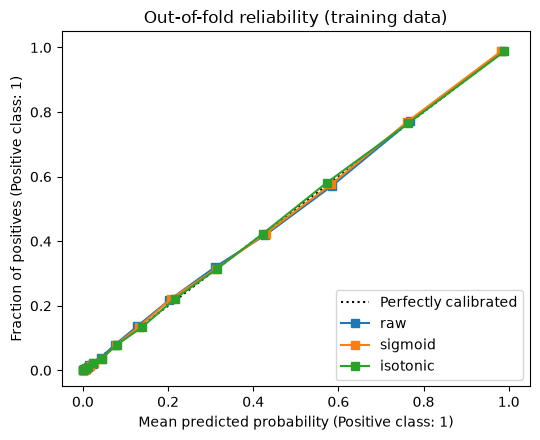

In [72]:
from sklearn.metrics import log_loss
from sklearn.model_selection import cross_val_predict

candidates = {
    "raw": best_hgb,
    "sigmoid": CalibratedClassifierCV(best_hgb, method="sigmoid", cv=StratifiedKFold(5, shuffle=True, random_state=SEED)),
    "isotonic": CalibratedClassifierCV(best_hgb, method="isotonic", cv=StratifiedKFold(5, shuffle=True, random_state=SEED)),
}
oof = {}
cal_rows = []
for name, model in candidates.items():
    oof[name] = cross_val_predict(model, Xp_train, yp_train, cv=project_cv, method="predict_proba", n_jobs=5)[:, 1]
    cal_rows.append({"probabilities": name, "Brier": brier_score_loss(yp_train, oof[name]), "log loss": log_loss(yp_train, oof[name])})
calibration_table = pd.DataFrame(cal_rows).set_index("probabilities")
best_method = calibration_table["Brier"].idxmin()
brier_gain = calibration_table.loc["raw", "Brier"] - calibration_table.loc[best_method, "Brier"]
print(calibration_table.to_string(float_format="{:.5f}".format))

# Calibration costs 5× the training time; only use it if it helps by a meaningful margin
MIN_BRIER_GAIN = 0.0005
chosen_calibration = best_method if brier_gain >= MIN_BRIER_GAIN else "raw"
print(f"\nbest method: {best_method} (Brier gain over raw {brier_gain:.5f}) → using '{chosen_calibration}' probabilities")

fig, ax = plt.subplots(figsize=(5.5, 4.5))
for name in candidates:
    CalibrationDisplay.from_predictions(yp_train, oof[name], n_bins=15, strategy="quantile", name=name, ax=ax)
ax.set_title("Out-of-fold reliability (training data)")
plt.tight_layout()
plt.show()

### Step 7 — Tune the decision threshold for profit

`TunedThresholdClassifierCV` searches thresholds with internal CV on the **training data**, using our profit function as the score, then refits the model chosen in Step 6 (raw or calibrated) on all training rows.

fit took 9s
tuned threshold: 0.212 (theory for calibrated probabilities: 0.20)
CV profit per person at tuned threshold: $6.98
out-of-fold profit per person at 0.5: $5.76 | at theory 0.2: $6.97 | call everyone: $1.96


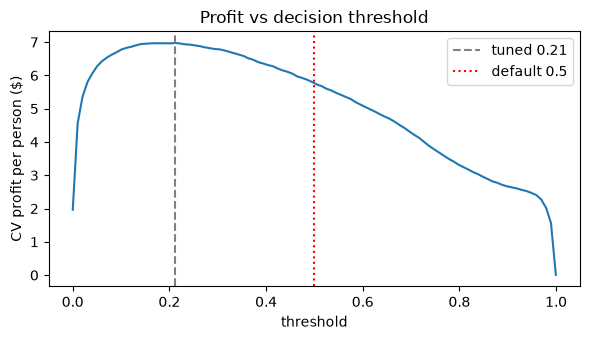

In [73]:
from sklearn.metrics import make_scorer

GAIN_TP, COST_FP = 40, 10


def campaign_profit(y_true, y_pred):
    """Average profit per person in the list: +$40 per high earner called, −$10 per other call."""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    return (GAIN_TP * tp - COST_FP * fp) / len(y_true)


profit_scorer = make_scorer(campaign_profit)
final_base = candidates[chosen_calibration]

start = time.perf_counter()
final_model = TunedThresholdClassifierCV(final_base, scoring=profit_scorer, cv=project_cv,
                                         store_cv_results=True, n_jobs=5).fit(Xp_train, yp_train)
theory_threshold = COST_FP / (GAIN_TP + COST_FP)
p_oof = oof[chosen_calibration]
print(f"fit took {time.perf_counter() - start:.0f}s")
print(f"tuned threshold: {final_model.best_threshold_:.3f} (theory for calibrated probabilities: {theory_threshold:.2f})")
print(f"CV profit per person at tuned threshold: ${final_model.best_score_:.2f}")
print(f"out-of-fold profit per person at 0.5: ${campaign_profit(yp_train, p_oof >= 0.5):.2f} | "
      f"at theory 0.2: ${campaign_profit(yp_train, p_oof >= theory_threshold):.2f} | "
      f"call everyone: ${campaign_profit(yp_train, np.ones_like(yp_train)):.2f}")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(final_model.cv_results_["thresholds"], final_model.cv_results_["scores"])
ax.axvline(final_model.best_threshold_, ls="--", color="gray", label=f"tuned {final_model.best_threshold_:.2f}")
ax.axvline(0.5, ls=":", color="red", label="default 0.5")
ax.set(xlabel="threshold", ylabel="CV profit per person ($)", title="Profit vs decision threshold")
ax.legend()
plt.tight_layout()
plt.show()

### Step 8 — Final evaluation on the test set (once)

In [74]:
test_proba = final_model.predict_proba(Xp_test)[:, 1]
test_pred = final_model.predict(Xp_test)
assert np.array_equal(test_pred, (test_proba >= final_model.best_threshold_).astype(int))


def policy_row(name, calls):
    calls = np.asarray(calls).astype(int)
    return {"policy": name, "profit per person $": campaign_profit(yp_test, calls), "share called": calls.mean(),
            "precision": precision_score(yp_test, calls, zero_division=0), "recall": recall_score(yp_test, calls)}


final_table = pd.DataFrame([
    policy_row(f"model, tuned threshold {final_model.best_threshold_:.2f}", test_pred),
    policy_row("model, default threshold 0.50", test_proba >= 0.5),
    policy_row("call everyone", np.ones(len(yp_test))),
    policy_row("call nobody", np.zeros(len(yp_test))),
]).set_index("policy")
print(f"TEST ROC-AUC {roc_auc_score(yp_test, test_proba):.3f} | average precision {average_precision_score(yp_test, test_proba):.3f} "
      f"| Brier {brier_score_loss(yp_test, test_proba):.4f}")
tuned_profit, default_profit = final_table["profit per person $"].iloc[0], final_table["profit per person $"].iloc[1]
print(f"tuned threshold earns ${tuned_profit - default_profit:+.2f} per person vs the default threshold "
      f"(≈ ${(tuned_profit - default_profit) * 100_000:+,.0f} on a 100,000-person list)")
final_table

TEST ROC-AUC 0.929 | average precision 0.833 | Brier 0.0870
tuned threshold earns $+1.12 per person vs the default threshold (≈ $+111,987 on a 100,000-person list)


,profit per person $,share called,precision,recall
policy,,,,
"model, tuned threshold 0.21",6.977,0.364,0.584,0.887
"model, default threshold 0.50",5.857,0.199,0.789,0.656
call everyone,1.966,1.000,0.239,1.000
call nobody,0.000,0.000,0.000,0.000


In [75]:
print(classification_report(yp_test, test_pred, target_names=["<=50K", ">50K"], digits=3))

# Fairness audit: sex was not a feature, but proxies (e.g. relationship = 'Husband'/'Wife') exist
audit = pd.DataFrame({"sex": X_adult.loc[Xp_test.index, "sex"], "y": yp_test, "called": test_pred})
audit_table = audit.groupby("sex", observed=True).apply(
    lambda g: pd.Series({"people": len(g), "actual >50K rate": g["y"].mean(), "share called": g["called"].mean(),
                         "recall": recall_score(g["y"], g["called"]), "precision": precision_score(g["y"], g["called"])}),
    include_groups=False,
)
audit_table

              precision    recall  f1-score   support

       <=50K      0.958     0.801     0.872      7431
        >50K      0.584     0.887     0.704      2338

    accuracy                          0.821      9769
   macro avg      0.771     0.844     0.788      9769
weighted avg      0.868     0.821     0.832      9769



,people,actual >50K rate,share called,recall,precision
sex,,,,,
Female,3259.0,0.111,0.164,0.812,0.549
Male,6510.0,0.304,0.464,0.901,0.590


### Step 9 — Save, reload, and verify

In [76]:
bundle_path = OUTPUT_DIR / "adult_campaign_model.joblib"
joblib.dump(final_model, bundle_path)
(OUTPUT_DIR / "adult_campaign_model.meta.json").write_text(json.dumps({
    "sklearn_version": sklearn.__version__, "features": FEATURES, "threshold": float(final_model.best_threshold_),
    "calibration": chosen_calibration, "gain_tp": GAIN_TP, "cost_fp": COST_FP,
}, indent=2))

loaded_model = joblib.load(bundle_path)
assert np.array_equal(loaded_model.predict(Xp_test), test_pred)
assert np.allclose(loaded_model.predict_proba(Xp_test)[:, 1], test_proba)

new_person = pd.DataFrame([{**Xp_test.iloc[0].to_dict()}])[FEATURES].astype(Xp_test.dtypes.to_dict())
print(f"✅ reloaded model reproduces all {len(Xp_test):,} test predictions | file {bundle_path.stat().st_size / 1024:.0f} KB")
print(f"example person → P(>50K) = {loaded_model.predict_proba(new_person)[0, 1]:.3f}, call = {bool(loaded_model.predict(new_person)[0])}")

✅ reloaded model reproduces all 9,769 test predictions | file 435 KB
example person → P(>50K) = 0.176, call = False


**Stretch goals**
1. Replace the fixed $40 / $10 with a per-person value (e.g. margin grows with predicted income) and pass it to the scorer through `sample_weight` with metadata routing.
2. Add `TargetEncoder` for `native-country` and `occupation` to the logistic-regression pipeline and see whether it closes the gap to gradient boosting.
3. Wrap Steps 5–7 in an outer `cross_validate` loop (nested CV) to estimate the profit of the *whole* procedure, not just the chosen model.
4. Compute permutation importance of the final model on a validation split and check whether `relationship` (a proxy for sex) drives decisions.

### 🗣️ How to talk about this in an interview
- "I framed the problem as **profit per contacted person** with a gain of $40 per true positive and a $10 cost per false positive, which implies a probability cut-off of 0.2 if the model is calibrated — then I let `TunedThresholdClassifierCV` find the threshold with cross-validation on training data and compared it with that theory."
- "Every preprocessing step lived in a **pipeline**, model selection used 5-fold stratified CV on the training set, and the test set was used **exactly once** at the end."
- "I compared a linear model, a random forest, and histogram gradient boosting on log loss, tuned the winner with randomized search — and kept the defaults when tuning didn't beat them on the same folds — then checked calibration with out-of-fold Brier scores and only added a calibrator if it clearly helped."
- "On the test set I reported profit against simple policies (call everyone, call nobody, default 0.5 threshold), not just AUC — that's the number the business cares about."
- "I excluded sensitive attributes from the features but still **audited recall and contact rates by sex**, because proxies like relationship status can reintroduce bias."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. What is data leakage, and how does a scikit-learn `Pipeline` prevent it?**

<details><summary>Show answer</summary>

- **30-second answer:** Leakage is when information from validation/test data (or the future) influences training, so offline scores are too optimistic. A `Pipeline` bundles preprocessing and model into one estimator, so during cross-validation every step is `fit` on the training fold only and the validation fold is only `transform`ed.
- **Go deeper:** Pipelines fix *preprocessing* leakage (scaling, imputation, feature selection, target encoding). They do not fix *split* leakage — the same user in train and validation (use `GroupKFold`), future rows in training (use `TimeSeriesSplit`), or features that are only known after the outcome (fix the feature set). In Section 4, selecting features on all rows turned pure noise into ~80% "accuracy".
- **❌ Common wrong answer:** "Leakage only happens if the test set is literally in the training data."

</details>

**Q2. When would you use `StratifiedKFold`, `GroupKFold`, or `TimeSeriesSplit`?**

<details><summary>Show answer</summary>

- **30-second answer:** Stratified for classification so each fold keeps the class ratio; Group when several rows share an entity (patient, user, store) so the entity never appears on both sides; TimeSeries when you predict the future, so validation always comes after training.
- **Go deeper:** `StratifiedGroupKFold` combines the first two. `TimeSeriesSplit(gap=...)` leaves a buffer when labels arrive late or features use rolling windows. The rule: the CV split must mimic how the model meets new data in production.
- **❌ Common wrong answer:** "Always shuffle and use KFold — more randomness is better."

</details>

**Q3. What is nested cross-validation, and why is `GridSearchCV.best_score_` optimistic?**

<details><summary>Show answer</summary>

- **30-second answer:** `best_score_` is the maximum of many noisy CV estimates computed on the same folds used to choose the winner, so it is biased upward. Nested CV puts the whole search inside an outer CV loop; the outer folds score models whose hyperparameters were chosen without them.
- **Go deeper:** In code: `cross_val_score(GridSearchCV(pipe, grid, cv=inner), X, y, cv=outer)`. The bias grows with the size of the search space and shrinks with more data (Cawley & Talbot, 2010). Nested CV evaluates the *procedure*; you still deploy the search refit on all training data.
- **❌ Common wrong answer:** "Nested CV gives you the best hyperparameters." It gives an honest estimate; each outer fold may pick different hyperparameters.

</details>

**Q4. Grid search vs random search vs successive halving — when do you use each?**

<details><summary>Show answer</summary>

- **30-second answer:** Grid for a few hyperparameters with known candidate values; random search for larger spaces because every trial tries new values of every hyperparameter; successive halving (`HalvingRandomSearchCV`) when fits are expensive — many candidates on little data, keep the best third, repeat with more data.
- **Go deeper:** Random search wins when only a few hyperparameters matter (Bergstra & Bengio, 2012). Halving assumes that ranking on small budgets predicts ranking on large budgets, which can fail for models that need lots of data. Bayesian optimisation (Optuna) is the next step up.
- **❌ Common wrong answer:** "Grid search is always best because it is exhaustive." It is exhaustive only over the points you listed.

</details>

**Q5. How do you handle an imbalanced classification problem?**

<details><summary>Show answer</summary>

- **30-second answer:** Choose a metric that matches the business (PR-AUC, recall at fixed precision, expected cost), use stratified splits, start with a well-calibrated model, and **tune the decision threshold** on validation data (`TunedThresholdClassifierCV`). Class weights or resampling are optional extras.
- **Go deeper:** `class_weight="balanced"` and oversampling change the training distribution, so predicted probabilities are inflated (Section 10) — recalibrate if you use them. Resampling must happen inside the training folds. Accuracy is misleading: a "predict nothing" model can be 99% accurate on 1% fraud.
- **❌ Common wrong answer:** "Always apply SMOTE" or "just use accuracy with a 0.5 threshold."

</details>

**Q6. What is probability calibration, how do you check it, and when does it matter?**

<details><summary>Show answer</summary>

- **30-second answer:** A calibrated model's "70%" happens about 70% of the time. Check with a reliability diagram (`CalibrationDisplay`) and the Brier score or log loss; fix with `CalibratedClassifierCV` (sigmoid for small data, isotonic for larger data). It matters whenever probabilities feed decisions: expected cost, risk scores, ranking under a budget.
- **Go deeper:** Logistic regression is usually well calibrated; SVMs have no probabilities; naive Bayes and heavily regularised or class-weighted models are often miscalibrated. Calibrate on data the model was not trained on (`cv=5`, or `FrozenEstimator` + held-out set). Calibration does not change ROC-AUC much because it (mostly) preserves the ranking.
- **❌ Common wrong answer:** "High AUC means the probabilities are accurate."

</details>

**Q7. Impurity-based vs permutation feature importance — what are the pitfalls?**

<details><summary>Show answer</summary>

- **30-second answer:** Impurity (MDI) importance is computed from training splits and is biased toward continuous and high-cardinality features — random noise can rank highly. Permutation importance measures the score drop when a column is shuffled on held-out data, so it reflects generalisation, but correlated features share credit and both can look unimportant.
- **Go deeper:** Compute permutation importance on validation data with several repeats; group or drop correlated features (Section 12 showed `education-num` gaining importance when its twin was removed); SHAP gives per-prediction explanations. None of these is causal (Strobl et al., 2007).
- **❌ Common wrong answer:** "`feature_importances_` tells you which features cause the outcome."

</details>

**Q8. Which models need feature scaling, and why?**

<details><summary>Show answer</summary>

- **30-second answer:** Models that use distances, dot products, or penalised weights: kNN, SVM, logistic/linear regression with regularisation, PCA, KMeans, neural networks. Tree-based models (decision trees, random forests, gradient boosting) split one feature at a time, so rescaling does not change them.
- **Go deeper:** With L2 regularisation, unscaled features get penalised unequally, so the "same" model changes with units. Ensembles like `StackingClassifier` do not scale anything for you — scale inside each base model's pipeline (Pitfall 3).
- **❌ Common wrong answer:** "Scaling always improves accuracy" or "stacking handles scaling internally."

</details>

**Q9. How do you encode a categorical feature with 10,000 levels?**

<details><summary>Show answer</summary>

- **30-second answer:** One-hot creates 10,000 sparse columns and can still work for linear models, but target encoding (`TargetEncoder`) or native categorical support (`HistGradientBoostingClassifier`, CatBoost) is usually better. Target encoding must be cross-fitted and learned only on training folds, or it leaks the label.
- **Go deeper:** `TargetEncoder.fit_transform` uses internal cross fitting plus smoothing toward the global mean for rare categories, so `fit_transform(X)` ≠ `fit(X).transform(X)`. Alternatives: `OneHotEncoder(min_frequency=..., max_categories=...)` to group rare levels, hashing, or learned embeddings.
- **❌ Common wrong answer:** "Replace each category with its mean target computed on the whole dataset."

</details>

### 💻 Coding

**Q10. Write a leak-free training setup for a table with numeric and categorical columns, some missing values.**

<details><summary>Show answer</summary>

- **30-second answer:**
  ```python
  pre = ColumnTransformer([
      ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), make_column_selector(dtype_include="number")),
      ("cat", make_pipeline(SimpleImputer(strategy="most_frequent"), OneHotEncoder(handle_unknown="ignore")),
       make_column_selector(dtype_include=["object", "category"])),
  ])
  model = make_pipeline(pre, LogisticRegression(max_iter=1000))
  scores = cross_val_score(model, X_train, y_train, cv=StratifiedKFold(5, shuffle=True, random_state=0), scoring="roc_auc")
  ```
- **Go deeper:** Split off the test set first; tune with `GridSearchCV(model, {"logisticregression__C": [...]})`; for tree boosting, skip one-hot and use `HistGradientBoostingClassifier` with pandas categories. `handle_unknown="ignore"` keeps production from crashing on new categories.
- **❌ Common wrong answer:** Calling `scaler.fit_transform(X)` on the full dataset before `train_test_split`.

</details>

**Q11. Implement a custom transformer. What rules must it follow to work with `GridSearchCV`?**

<details><summary>Show answer</summary>

- **30-second answer:** Inherit `TransformerMixin, BaseEstimator`; `__init__` only stores its arguments under the same names; `fit` learns attributes ending in `_` and returns `self`; `transform` uses only fitted attributes.
- **Go deeper:** `clone` rebuilds the estimator from `get_params()`, so logic in `__init__` breaks grid search silently. Add `get_feature_names_out` so `set_output(transform="pandas")` and `ColumnTransformer` naming work; use `check_is_fitted` in `transform`; `sklearn.utils.estimator_checks.check_estimator` tests API compliance.
- **❌ Common wrong answer:** Forgetting `return self` in `fit`, or validating/transforming parameters in `__init__`.

</details>

### 🐛 Debugging Scenarios

**Q12. Cross-validated AUC is 0.95, but the model scores 0.70 in production. What do you investigate?**

<details><summary>Show answer</summary>

- **30-second answer:** (1) Split leakage: are the same users/patients in train and validation, or future data in training? Re-run CV with `GroupKFold` / a time-based split. (2) Feature leakage: any feature only known after the label? (3) Preprocessing fit outside the pipeline. (4) Train/serve skew: different preprocessing code or data sources in production. (5) Distribution shift over time.
- **Go deeper:** Compare feature distributions between training and live data, check permutation importance for suspiciously dominant features (IDs, timestamps), and replay a week of production inputs through the saved pipeline to rule out skew.
- **❌ Common wrong answer:** "The model is overfitting — add regularisation." Overfitting shows up *in* CV; a CV-vs-production gap usually means the CV was not like production.

</details>

**Q13. A teammate sends you `model.pkl` from the internet and a notebook that loads it. Any concerns?**

<details><summary>Show answer</summary>

- **30-second answer:** Yes — loading a pickle or joblib file can execute arbitrary code, so never load untrusted files. Also, a model saved with a different scikit-learn version may raise `InconsistentVersionWarning` and behave differently.
- **Go deeper:** Use `skops.io`, which lists unknown types for review before loading (`get_untrusted_types`), or retrain from code and data you control. Store the library versions and a checksum next to every artefact, and verify predictions on a fixed sample after loading.
- **❌ Common wrong answer:** "Pickle is just a data format, it's safe."

</details>

### 🏗️ Design

**Q14. Design a lead-scoring model where a call costs $10 and a converted lead is worth $40.**

<details><summary>Show answer</summary>

- **30-second answer:** Define the objective as expected profit, not accuracy. Build a leak-free pipeline, pick a model with good log loss, calibrate probabilities, then call when $p > 10/(40+10) = 0.2$ — or tune the threshold on validation data with a profit scorer (`TunedThresholdClassifierCV`). Report test profit against "call everyone" and "call nobody" baselines.
- **Go deeper:** If the call budget is fixed, rank by expected value and take the top N instead of a threshold. Monitor calibration and conversion rates after launch (drift changes the optimal threshold), run an A/B test against the current process, and audit outcomes across sensitive groups.
- **❌ Common wrong answer:** "Use 0.5 and maximise F1."

</details>

## 🧪 Quick Quiz

Predict the output, then reveal.

**1.** `StandardScaler().fit([[1], [3]]).transform([[5]])`
<details><summary>Answer</summary>

`array([[3.]])` — the scaler learned mean 2 and standard deviation 1, so (5 − 2) / 1 = 3. `transform` never re-learns.
</details>

**2.** `GridSearchCV(model, {"max_depth": [1, 2, 3], "min_samples_leaf": [1, 5]}, cv=5)` with the default `refit=True`. How many fits?
<details><summary>Answer</summary>

**31** — 3 × 2 = 6 candidates × 5 folds = 30, plus 1 refit of the best candidate on all the data.
</details>

**3.** Which one raises `AttributeError`: `KMeans(3).fit(X).predict(X)` or `DBSCAN().fit(X).predict(X)`?
<details><summary>Answer</summary>

`DBSCAN` — it has `fit_predict` but no `predict`, because clusters are defined by the density of the training points. `KMeans` can assign new points to the nearest centroid.
</details>

**4.** `OneHotEncoder().fit([["a"], ["b"]]).transform([["c"]])`
<details><summary>Answer</summary>

`ValueError: Found unknown categories ['c'] in column 0 during transform` — the default is `handle_unknown="error"`. Use `"ignore"` or `"infrequent_if_exist"` in production.
</details>

**5.** `train, test = train_test_split(list(range(10)), test_size=0.25, random_state=0)` — how many items are in `test`?
<details><summary>Answer</summary>

**3** — the test size is rounded **up** (`ceil(0.25 × 10) = 3`), and the training set gets the remaining 7.
</details>

## 📚 Resources

### 📖 Official Docs
- [Common pitfalls and recommended practices](https://scikit-learn.org/stable/common_pitfalls.html) — leakage, inconsistent preprocessing, and randomness, from the maintainers
- [Cross-validation: evaluating estimator performance](https://scikit-learn.org/stable/modules/cross_validation.html) — every splitter, with diagrams
- [Tuning the decision threshold for class prediction](https://scikit-learn.org/stable/modules/classification_threshold.html) — `TunedThresholdClassifierCV` and `FixedThresholdClassifier`
- [Probability calibration](https://scikit-learn.org/stable/modules/calibration.html) — reliability diagrams, sigmoid vs isotonic
- [Permutation feature importance](https://scikit-learn.org/stable/modules/permutation_importance.html) — including the MDI-vs-permutation comparison
- [Model persistence](https://scikit-learn.org/stable/model_persistence.html) — pickle, joblib, skops, ONNX, and their security trade-offs
- [Developing scikit-learn estimators](https://scikit-learn.org/stable/developers/develop.html) — the full contract for custom estimators

### 🎥 Videos
- [Data School (Kevin Markham) — Machine learning in Python with scikit-learn](https://www.youtube.com/playlist?list=PL5-da3qGB5ICeMbQuqbbCOQWcS6OYBr5A) (playlist) — the classic beginner series: train/test, cross-validation, grid search, and evaluation metrics, explained slowly and clearly
- [freeCodeCamp — Scikit-learn Crash Course (taught by Vincent Warmerdam)](https://www.youtube.com/watch?v=0B5eIE_1vpU) (~2 h 9 min) — pipelines, preprocessing, grid search and metrics, taught by the creator of calmcode and scikit-lego; a good second pass on Sections 3–8
- [StatQuest (Josh Starmer) — Machine Learning Fundamentals: Cross Validation](https://www.youtube.com/watch?v=fSytzGwwBVw) (~6 min) — the picture behind k-fold CV in a few minutes
- [StatQuest (Josh Starmer) — ROC and AUC, Clearly Explained!](https://www.youtube.com/watch?v=4jRBRDbJemM) (~16 min) — what the ROC curve and thresholds really mean, before you tune one

### 📄 Papers
- [Pedregosa et al. (2011) — Scikit-learn: Machine Learning in Python, *JMLR*](https://jmlr.org/papers/v12/pedregosa11a.html) — the original library paper
- [Buitinck et al. (2013) — API design for machine learning software: experiences from the scikit-learn project](https://arxiv.org/abs/1309.0238) — why estimators, transformers, and pipelines look the way they do
- [Cawley & Talbot (2010) — On Over-fitting in Model Selection and Subsequent Selection Bias in Performance Evaluation, *JMLR*](https://jmlr.org/papers/v11/cawley10a.html) — the case for nested cross-validation
- [Bergstra & Bengio (2012) — Random Search for Hyper-Parameter Optimization, *JMLR*](https://jmlr.org/papers/v13/bergstra12a.html) — why random beats grid search
- [Jamieson & Talwalkar (2015) — Non-stochastic Best Arm Identification and Hyperparameter Optimization](https://arxiv.org/abs/1502.07943) — successive halving
- [Strobl et al. (2007) — Bias in random forest variable importance measures, *BMC Bioinformatics*](https://bmcbioinformatics.biomedcentral.com/articles/10.1186/1471-2105-8-25) — why impurity importance favours some features

### 📘 Books & Courses
- [scikit-learn MOOC (Inria, free)](https://inria.github.io/scikit-learn-mooc/) — the official course by the core developers, with exercises
- [An Introduction to Statistical Learning (free PDF, Python edition)](https://www.statlearning.com/) — the theory behind CV, trees, and regularisation
- [Kaggle Learn — Intermediate Machine Learning](https://www.kaggle.com/learn/intermediate-machine-learning) — short hands-on lessons on pipelines, leakage, and categorical data

### 🏋️ Practice
- [OpenML datasets](https://www.openml.org/search?type=data) — thousands of real tabular datasets loadable with `fetch_openml`
- [Kaggle Playground Series](https://www.kaggle.com/competitions?searchQuery=playground) — monthly tabular competitions to practise the full pipeline

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / rule |
|---|---|---|
| Estimator API | learn, then apply | `fit` → `predict` / `transform`; learned attributes end in `_`; `clone` |
| Splits | honest evaluation | `train_test_split(..., stratify=y, random_state=...)`; touch the test set once |
| Preprocessing | numbers without gaps | `SimpleImputer`, `StandardScaler`, `OneHotEncoder(handle_unknown=...)`, `TargetEncoder`, `ColumnTransformer`, `set_output(transform="pandas")` |
| Pipelines | no preprocessing leakage | `make_pipeline(pre, model)`; params as `step__param` |
| Cross-validation | reliable scores | `StratifiedKFold`, `GroupKFold`, `TimeSeriesSplit`, `cross_validate` |
| Model zoo | pick a family | baseline `DummyClassifier` → `LogisticRegression` → `HistGradientBoostingClassifier` |
| Metrics | match the business | `classification_report`, `roc_auc_score`, `average_precision_score`, `root_mean_squared_error`, `*Display` |
| Search | tune hyperparameters | `GridSearchCV`, `RandomizedSearchCV`, `HalvingRandomSearchCV` (experimental import) |
| Nested CV | unbiased estimate of tuning | `cross_val_score(GridSearchCV(...), X, y, cv=outer)` |
| Imbalance | decisions that pay | `class_weight`, `TunedThresholdClassifierCV`, `FixedThresholdClassifier` |
| Calibration | honest probabilities | `CalibratedClassifierCV`, `CalibrationDisplay`, `brier_score_loss`, `FrozenEstimator` |
| Unsupervised | structure without labels | scale first; `KMeans` + silhouette; `PCA`; `DBSCAN(eps, min_samples)` |
| Importance | what the model uses | `permutation_importance` on held-out data > `feature_importances_` |
| Custom transformers | your own steps | `TransformerMixin, BaseEstimator`; `fit` returns `self`; nothing in `__init__` |
| Persistence | ship the pipeline | `joblib.dump/load` (trusted files only), `skops.io`, record versions, fix `random_state` |

## ➡️ What's Next

**[03 · Linear Regression](03_Linear_Regression.ipynb)** — you now know the scikit-learn workflow. The next notebooks go **one algorithm at a time**: linear and logistic regression, KNN, Naive Bayes, SVMs, decision trees, random forests, [gradient boosting](10_Gradient_Boosting.ipynb), ensembles, clustering, dimensionality reduction and more — each with the intuition, the math, a from-scratch build, and the best library for the job.